# Logistic Regression Model vs Random Forrest to improve performance of Cross-Asset Filer Trading Algorithm
**Project:** Cross-Asset Contradiction & Momentum Strategy  
**Asset Classes:** Equity Futures (NQ) & Cryptocurrency (BTC)  
**Timeframe:** 1-Minute Data  

### Executive Summary
This notebook tests how do ML models improve the performance of the trading algorithm using Logistic Regression and Random Forrest with Rolling Cross-Validation

### Structure:
1.  **Data Engine:** Synchronization of NQ and BTC timelines.
2.  **Strategy Engine (Naked):** Pure momentum strategy based solely on candle alignment (No filters).
3.  **Feature Engineering:** Choosing which features to include in the ML model.
4.  **Linear/Logistic Regression:** Models to improve the algorithms efficiency.
5.  **Performance Analysis:** Equity Curve Comparison, Sharpe Ratio.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# --- CONFIGURATION ---
FILE_BTC = r"C:\Python\data-sets\BINANCE_BTC_Oct_Dec.csv"
FILE_NQ = r"C:\Python\data-sets\READY_NQ_Oct_Dec.csv"

# Hard Close Time (Safety Mechanism) in UTC time
CLOSE_HOUR = 21
CLOSE_MINUTE = 55

# Settings
pd.set_option('display.max_columns', None)
print("Environment Configured.")

Environment Configured.


## 1. Data Engine
The `DataEngine` class is responsible for loading raw CSV files, standardizing column names, synchronizing timestamps (to handle different timezones), and merging the datasets into a single timeline.

In [3]:
class DataEngine:
    def __init__(self, path_btc, path_nq):
        self.path_btc = path_btc
        self.path_nq = path_nq

    def load_data(self):
        try:
            df_btc = pd.read_csv(self.path_btc, sep=None, engine='python')
            df_nq = pd.read_csv(self.path_nq, sep=None, engine='python')
        except FileNotFoundError:
            print("ERROR: Files not found.")
            return None

        def clean(df, suffix):
            # Czyszczenie nazw kolumn
            df.columns = [c.strip().lower() for c in df.columns]
            rename = {}
            for c in df.columns:
                if 'time' in c and 'utc' not in c: rename[c] = 'time'
                elif 'close' in c: rename[c] = f'close_{suffix}'
                elif 'open' in c: rename[c] = f'open_{suffix}'
                elif 'high' in c: rename[c] = f'high_{suffix}'
                elif 'low' in c: rename[c] = f'low_{suffix}'
            
            df = df.rename(columns=rename)
            
            # Obsługa czasu
            if 'time' in df.columns:
                df['time'] = df['time'].astype('int64')
                # UWAGA: Sztywne +1h. Upewnij się, że to pasuje do Twojej strefy czasowej (Zima/Lato)
                df['datetime'] = pd.to_datetime(df['time'], unit='s') + pd.Timedelta(hours=1)
            return df

        df_btc = clean(df_btc, 'btc')
        df_nq = clean(df_nq, 'nq')

        # Łączenie danych (Inner join - zostawia tylko wspólne świece)
        merged = pd.merge(df_btc, df_nq, on='datetime', how='inner', suffixes=('', '_del'))
        merged = merged.loc[:, ~merged.columns.str.endswith('_del')]
        merged.set_index('datetime', inplace=True)
        merged.sort_index(inplace=True)
        
        # Filtrowanie weekendów (0=Mon, 4=Fri)
        merged = merged[merged.index.dayofweek < 5] 
        merged.dropna(inplace=True)
        
        # Obliczenia pomocnicze (do analizy, nie wpływają na logikę strategii bezpośrednio)
        merged['ret_btc'] = merged['close_btc'].pct_change()
        merged['ret_nq'] = merged['close_nq'].pct_change()
        merged['rolling_corr'] = merged['ret_btc'].rolling(60).corr(merged['ret_nq'])
        
        merged.dropna(inplace=True)
        print(f"Data Loaded: {len(merged)} candles.")
        return merged

# Load Data
engine = DataEngine(FILE_BTC, FILE_NQ)
market_data = engine.load_data()

Data Loaded: 71369 candles.


## 2. Naked Strategy Engine
This strategy executes trades based **only** on the directional agreement between BTC and NQ (which will be further enhanced by adding indicators)

* Hard Time Close (22:55) and Gap Protection (Risk Management is mandatory for valid backtesting).

Running Enhanced Strategy Engine...

Total Trades: 28368
Total Points: 1373.50

Exit Reasons Breakdown:
Reason
Divergence         16050
Reversal (Stop)    12318
Name: count, dtype: int64


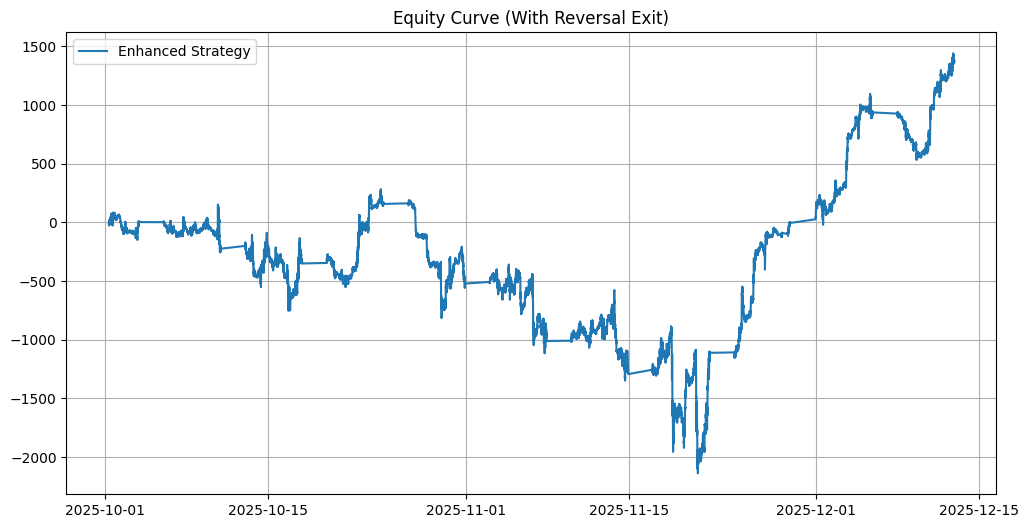

In [4]:
class StrategyEngine:
    def __init__(self, data):
        self.df = data.copy()
        
        # Ustawienia wyjścia czasowego (Hard Close)
        # Upewnij się, że pasują do Twoich danych (czy to 21:55 czy 22:55)
        self.CLOSE_HOUR = 21 
        self.CLOSE_MINUTE = 55

    def run(self):
        trades = []
        position = 0      
        entry_price = 0.0
        entry_time = None
        
        # Konwersja do listy słowników (przyspiesza pętlę ok. 50x względem iterrows)
        data = self.df.reset_index().to_dict('records')

        for i in range(len(data) - 1):
            row = data[i]
            next_row = data[i+1] 
            
            curr_time = row['datetime']
            
            # --- SAFETY TIME (Hard Close) ---
            is_eod = (curr_time.hour == self.CLOSE_HOUR and curr_time.minute >= self.CLOSE_MINUTE) \
                     or (curr_time.hour > self.CLOSE_HOUR)
            
            # Obliczamy kierunki na bieżącej świecy
            dir_btc = np.sign(row['close_btc'] - row['open_btc'])
            dir_nq = np.sign(row['close_nq'] - row['open_nq'])

            # =========================================
            #           LOGIKA WYJŚCIA (EXIT)
            # =========================================
            if position != 0:
                # 1. DIVERGENCE (Stary warunek): Sygnały się rozjeżdżają
                is_divergence = (dir_btc != dir_nq)
                
                # 2. REVERSAL (Nowy warunek): Oba sygnały idą PRZECIWKO mnie
                # Jeśli mam Longa (1) i oba są (-1) -> Prawda
                # Jeśli mam Shorta (-1) i oba są (1) -> Prawda
                is_reversal = (dir_btc == -position) and (dir_nq == -position)
                
                # Decyzja o wyjściu
                if is_eod or is_divergence or is_reversal:
                    exit_price = row['close_nq']
                    pnl = (exit_price - entry_price) * position
                    duration = (curr_time - entry_time).total_seconds() / 60.0
                    
                    # Określenie powodu dla statystyk
                    if is_eod: reason = "EOD"
                    elif is_reversal: reason = "Reversal (Stop)"
                    else: reason = "Divergence"
                    
                    trades.append({
                        'Entry Time': entry_time, 
                        'Exit Time': curr_time,
                        'Type': "LONG" if position == 1 else "SHORT",
                        'Entry Price': entry_price, 
                        'Exit Price': exit_price,
                        'Points': pnl, 
                        'Duration (min)': duration, 
                        'Reason': reason
                    })
                    
                    position = 0
                    if is_eod: continue

            # =========================================
            #           LOGIKA WEJŚCIA (ENTRY)
            # =========================================
            if position == 0 and not is_eod:
                # Ochrona przed otwieraniem tuż przed zamknięciem (np. 5 min przed)
                if curr_time.hour == self.CLOSE_HOUR and curr_time.minute >= (self.CLOSE_MINUTE - 5):
                    continue

                # Czysty sygnał: Zgodność kierunków
                if dir_btc == 1 and dir_nq == 1:
                    position = 1
                    entry_price = next_row['open_nq'] 
                    entry_time = next_row['datetime']
                    
                elif dir_btc == -1 and dir_nq == -1:
                    position = -1
                    entry_price = next_row['open_nq']
                    entry_time = next_row['datetime']

        return pd.DataFrame(trades)

# --- URUCHOMIENIE ---
if market_data is not None and not market_data.empty:
    print("Running Enhanced Strategy Engine...")
    strategy = StrategyEngine(market_data)
    results = strategy.run()

    if not results.empty:
        print(f"\nTotal Trades: {len(results)}")
        print(f"Total Points: {results['Points'].sum():.2f}")
        
        # Statystyki powodów wyjścia (zobaczysz ile razy uratował Cię Reversal)
        print("\nExit Reasons Breakdown:")
        print(results['Reason'].value_counts())

        # Wykres Equity
        results['Cumulative'] = results['Points'].cumsum()
        plt.figure(figsize=(12, 6))
        plt.plot(results['Exit Time'], results['Cumulative'], label='Enhanced Strategy')
        plt.title('Equity Curve (With Reversal Exit)')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("No trades generated.")

## 3. Feature Engineering
### 3.1 Technical Filters
To improve the quality of signals and filter out "false positives" in noisy markets, the following classical technical indicators have been engineered:

* **EMA (Exponential Moving Average):**
    * *Purpose:* Trend Identification.
    * *Usage:* Helps filter out counter-trend trades (e.g., avoiding Longs when price is below EMA 50).
    
* **RSI (Relative Strength Index):**
    * *Purpose:* Momentum & Mean Reversion.
    * *Usage:* Identifies **Overbought (>70)** and **Oversold (<30)** conditions to prevent entering trades at the peak of a move.

* **MACD (Moving Average Convergence Divergence):**
    * *Purpose:* Trend Strength & Momentum.
    * *Usage:* Confirms the strength of the directional move using the Histogram and Signal line crossovers.

* **Bollinger Bands:**
    * *Purpose:* Volatility Analysis.
    * *Usage:* Measures market volatility and relative price levels. Helps identify "Squeeze" moments (low volatility) or breakout extensions.

In [5]:
def add_classic_indicators(df):
    """
    Dodaje klasyczne, popularne wskaźniki techniczne.
    Poprawiona wersja bez błędów zmiennych.
    """
    df = df.copy()
    
    # --- 1. EMA & SMA ---
    df['ema_50'] = df['close_nq'].ewm(span=50, adjust=False).mean()
    df['sma_20'] = df['close_nq'].rolling(window=20).mean()

    # --- 2. Bollinger Bands (20, 2) ---
    std_dev = df['close_nq'].rolling(window=20).std()
    df['bb_upper'] = df['sma_20'] + (std_dev * 2)
    df['bb_lower'] = df['sma_20'] - (std_dev * 2)
    
    # --- 3. RSI (14) ---
    delta = df['close_nq'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    
    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    df['rsi'] = df['rsi'].fillna(50) 

    # --- 4. MACD (12, 26, 9) ---
    exp12 = df['close_nq'].ewm(span=12, adjust=False).mean()
    exp26 = df['close_nq'].ewm(span=26, adjust=False).mean()
    
    df['macd_line'] = exp12 - exp26
    df['macd_signal'] = df['macd_line'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd_line'] - df['macd_signal']

    # --- 5. ATR (14) - POPRAWIONE ---
    # Najpierw liczymy ATR, a dopiero potem dropna, żeby nie ucinać danych dwa razy
    prev_close = df['close_nq'].shift(1)
    tr1 = df['high_nq'] - df['low_nq']
    tr2 = (df['high_nq'] - prev_close).abs()
    tr3 = (df['low_nq'] - prev_close).abs()
    
    df['tr'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    
    # TUTAJ BYŁ BŁĄD: Zmieniono 'window=period' na 'window=14'
    df['atr'] = df['tr'].rolling(window=14).mean()
    
    df['atr_pct'] = df['atr'] / df['close_nq']

    # --- CZYSZCZENIE ---
    # Dopiero teraz usuwamy wszystkie puste wiersze powstałe przez wskaźniki
    df.dropna(inplace=True)
    
    return df

# UŻYCIE
print("Calculating classic indicators...")
market_data = add_classic_indicators(market_data)
print(f"Features added correctly. Columns: {market_data.columns.tolist()}")

Calculating classic indicators...
Features added correctly. Columns: ['time', 'open_btc', 'high_btc', 'low_btc', 'close_btc', 'volume', 'open_nq', 'high_nq', 'low_nq', 'close_nq', 'ret_btc', 'ret_nq', 'rolling_corr', 'ema_50', 'sma_20', 'bb_upper', 'bb_lower', 'rsi', 'macd_line', 'macd_signal', 'macd_hist', 'tr', 'atr', 'atr_pct']


### 3.2 Time Feature Engine

In [6]:
def add_time_features(df):
    df = df.copy()
    
    # Podstawowe składniki
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute
    df['day_of_week'] = df.index.dayofweek # 0=Mon, 4=Fri
    
    # 1. HOUR FLOAT: Najważniejsze dla precyzyjnego filtrowania
    # Np. 14:30 zamieni się na 14.5. 21:15 na 21.25.
    # To pozwoli Ci powiedzieć: "Nie graj powyżej 20.5"
    df['time_float'] = df.index.hour + (df.index.minute / 60.0)
    
    # 2. SEZONY SESJI (Opcjonalne, ale super pod Regresję Logistyczną)
    # Możesz oznaczyć konkretne sesje jako "One-Hot" (0 lub 1)
    # Np. "Late NY" to czas od 19:00 do 22:00 czasu PL (zależy od Twoich danych)
    # Algorytm ML sam się nauczy, że ta kolumna ma negatywną wagę.
    df['is_eu_open'] = ((df['time_float'] >= 9.0) & (df['time_float'] < 11.0)).astype(int)
    df['is_ny_open'] = ((df['time_float'] >= 15.5) & (df['time_float'] < 17.0)).astype(int)
    df['is_late_session'] = (df['time_float'] >= 20.0).astype(int)

    return df

# APLIKACJA
market_data = add_time_features(market_data)

## 4. Data Set Generation & Labelling for Logistic Regression Model

In [7]:
# --- CELL: DATASET GENERATION (ENHANCED: DIV + REVERSAL EXIT) ---
import pandas as pd
import numpy as np

# Konfiguracja
SAFETY_CLOSE_HOUR = 21
SAFETY_CLOSE_MINUTE = 55

def get_trade_outcome_enhanced(entry_idx, df, entry_direction):
    """
    Symulacja z ulepszonym wyjściem (Enhanced Exit).
    Zamykamy pozycję w 3 przypadkach:
    1. EOD (Time) - Koniec dnia.
    2. Divergence - Sygnały się rozjeżdżają (jeden rośnie, drugi spada).
    3. Reversal (NOWOŚĆ) - Oba sygnały idą PRZECIWKO naszej pozycji.
    """
    entry_price = df.iloc[entry_idx]['open_nq']
    
    # Symulacja do max 600 minut (zakładamy sesję intraday)
    subset = df.iloc[entry_idx : entry_idx + 600]
    
    for i, row in subset.iterrows():
        current_idx = i
        curr_time = row['datetime']
        
        # --- 1. WARUNEK EOD ---
        is_eod = (curr_time.hour == SAFETY_CLOSE_HOUR and curr_time.minute >= SAFETY_CLOSE_MINUTE) or \
                 (curr_time.hour > SAFETY_CLOSE_HOUR)
        
        # --- Analiza kierunku świecy ---
        curr_dir_btc = np.sign(row['close_btc'] - row['open_btc'])
        curr_dir_nq = np.sign(row['close_nq'] - row['open_nq'])
        
        # --- 2. WARUNEK DYWERGENCJI (Rozjazd) ---
        # BTC i NQ idą w różne strony
        is_divergence = (curr_dir_btc != curr_dir_nq)
        
        # --- 3. WARUNEK REVERSAL (Odwrócenie) ---
        # Jeśli mamy Longa (1), a oba rynki spadają (-1) -> UCIEKAJ!
        # Jeśli mamy Shorta (-1), a oba rynki rosną (1) -> UCIEKAJ!
        # To chroni przed trzymaniem pozycji, gdy cały rynek krwawi.
        is_reversal = (curr_dir_btc == -entry_direction) and (curr_dir_nq == -entry_direction)
        
        # WYJŚCIE
        if is_eod or is_divergence or is_reversal:
            return (row['close_nq'] - entry_price) * entry_direction, current_idx

    # Fallback
    return (subset.iloc[-1]['close_nq'] - entry_price) * entry_direction, subset.index[-1]

def generate_labeled_dataset_enhanced(df):
    print("Generating candidates with ENHANCED logic (Div + Reversal)...")
    candidates = []
    df_reset = df.reset_index()
    
    for i in range(1, len(df_reset) - 605):
        row = df_reset.iloc[i]
        
        # Sygnał wejścia
        dir_btc = np.sign(row['close_btc'] - row['open_btc'])
        dir_nq = np.sign(row['close_nq'] - row['open_nq'])
        
        if dir_btc == dir_nq and dir_btc != 0:
            
            # Używamy nowej funkcji z Reversalem
            pnl, exit_idx = get_trade_outcome_enhanced(i+1, df_reset, dir_btc)
            
            candidates.append({
                'entry_idx': i+1,
                'exit_idx': exit_idx,
                'datetime': df_reset.iloc[i+1]['datetime'],
                'pnl': pnl,
                'target': 1 if pnl > 0 else 0,
                
                # Cechy (X)
                'rsi': row['rsi'],
                'atr_pct': row['atr_pct'],
                'hour': row['hour'], 
                'macd_hist': row['macd_hist'],
                'bb_width': (row['bb_upper'] - row['bb_lower']) / row['sma_20'],
                'dist_from_ema': (row['close_nq'] - row['ema_50']) / row['ema_50']
            })
            
    return pd.DataFrame(candidates)

# GENEROWANIE
ml_dataset = generate_labeled_dataset_enhanced(market_data)
ml_dataset = pd.get_dummies(ml_dataset, columns=['hour'], prefix='hour')

print(f"Dataset Ready. Candidates: {len(ml_dataset)}")
print(f"Total PnL (Vector Sum): {ml_dataset['pnl'].sum():.2f}")

Generating candidates with ENHANCED logic (Div + Reversal)...
Dataset Ready. Candidates: 41975
Total PnL (Vector Sum): 3367.75


## 5. Rolling Cross-Validation


--- STARTING OPTIMIZED WALK-FORWARD ANALYSIS ---
Window 0: Best Threshold=0.57 | ML PnL=-9.8
Window 1000: Best Threshold=0.50 | ML PnL=4.8
Window 2000: Best Threshold=0.51 | ML PnL=-18.8
Window 3000: Best Threshold=0.51 | ML PnL=336.2
Window 4000: Best Threshold=0.50 | ML PnL=-246.5
Window 5000: Best Threshold=0.50 | ML PnL=128.0
Window 6000: Best Threshold=0.51 | ML PnL=-48.0
Window 7000: Best Threshold=0.50 | ML PnL=99.0
Window 8000: Best Threshold=0.50 | ML PnL=-7.8
Window 9000: Best Threshold=0.50 | ML PnL=-79.8
Window 10000: Best Threshold=0.50 | ML PnL=125.8
Window 11000: Best Threshold=0.50 | ML PnL=45.2
Window 12000: Best Threshold=0.50 | ML PnL=-190.0
Window 13000: Best Threshold=0.54 | ML PnL=-125.5
Window 14000: Best Threshold=0.55 | ML PnL=-44.8
Window 15000: Best Threshold=0.50 | ML PnL=80.0
Window 16000: Best Threshold=0.52 | ML PnL=66.2
Window 17000: Best Threshold=0.51 | ML PnL=70.8
Window 18000: Best Threshold=0.51 | ML PnL=-64.0
Window 19000: Best Threshold=0.51 | ML

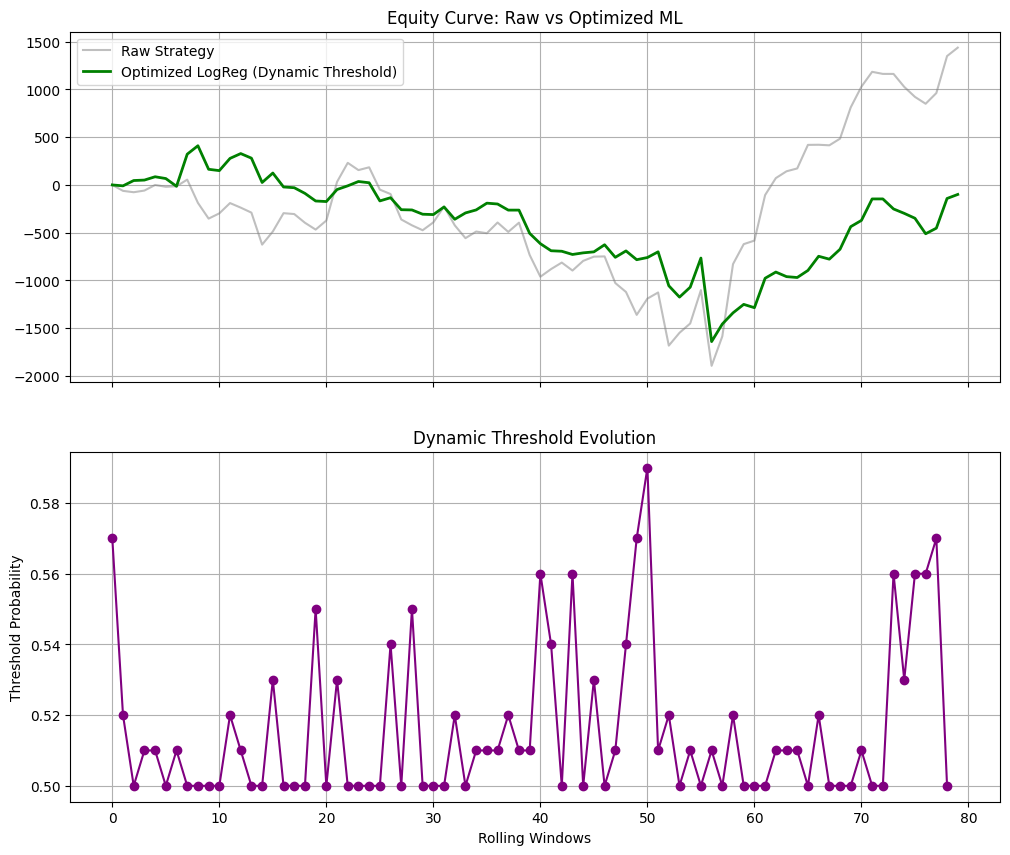

Final Raw: 1437.50
Final ML:  -99.75


In [8]:
# --- CELL: OPTIMIZED ROLLING CV (THRESHOLD TUNING) ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def optimize_threshold_on_train(model, X_train_scaled, df_train):
    """
    Szuka progu (threshold), który dałby największy zysk na danych TRENINGOWYCH.
    Dzięki temu uczymy się "charakterystyki modelu", nie patrząc w przyszłość.
    """
    best_threshold = 0.5
    best_pnl = -np.inf
    
    # Pobieramy prawdopodobieństwa dla zbioru treningowego
    probs_train = model.predict_proba(X_train_scaled)[:, 1]
    
    # Testujemy progi od 0.50 do 0.70 co 0.01
    thresholds = np.arange(0.50, 0.70, 0.01)
    
    for thr in thresholds:
        # Symulacja wyniku na zbiorze Train dla danego progu
        # (Uproszczona wektorowa symulacja dla szybkości - PnL sumaryczny)
        # Bierzemy tylko te trady, gdzie prob > thr
        mask = probs_train > thr
        pnl_sum = df_train.loc[mask, 'pnl'].sum()
        
        # Opcjonalnie: Dodajemy warunek minimalnej liczby tradów (żeby nie wybrał 1 tradu z gigantycznym zyskiem)
        n_trades = mask.sum()
        if n_trades > 10 and pnl_sum > best_pnl:
            best_pnl = pnl_sum
            best_threshold = thr
            
    return best_threshold

def run_rolling_cv_optimized(df, train_window=2000, step=500):
    print("\n--- STARTING OPTIMIZED WALK-FORWARD ANALYSIS ---")
    
    # Cechy (X)
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    # Model: Dodajemy C=0.1 (lekka regularyzacja, żeby nie przeuczyć)
    model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
    scaler = StandardScaler()
    
    equity_curve_ml = [0]
    equity_curve_raw = [0]
    threshold_history = [] # Do analizy, jak zmieniał się próg w czasie
    
    # Pętla Walk-Forward
    for start in range(0, len(df) - train_window - step, step):
        # 1. Podział
        train_df = df.iloc[start : start + train_window].reset_index(drop=True)
        test_df = df.iloc[start + train_window : start + train_window + step].reset_index(drop=True)
        
        X_train = train_df[features]
        y_train = train_df['target']
        X_test = test_df[features]
        
        # 2. Skalowanie
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # 3. Trening
        model.fit(X_train_scaled, y_train)
        
        # 4. --- OPTYMALIZACJA PROGU (NA ZBIORZE TRENINGOWYM!) ---
        # Pytamy: "Jaki próg działał najlepiej w przeszłości?"
        best_thr = optimize_threshold_on_train(model, X_train_scaled, train_df)
        threshold_history.append(best_thr)
        
        # 5. Predykcja na teście z użyciem zoptymalizowanego progu
        probs_test = model.predict_proba(X_test_scaled)[:, 1]
        
        # 6. Symulacja Handlu (No Overlap)
        last_exit_ml = -1
        pnl_period_ml = 0
        last_exit_raw = -1
        pnl_period_raw = 0
        
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            entry_idx = row['entry_idx']
            prob = probs_test[i]
            
            # ML Strategy (używamy best_thr zamiast 0.55)
            if entry_idx > last_exit_ml:
                if prob > best_thr: 
                    pnl_period_ml += row['pnl']
                    last_exit_ml = row['exit_idx']
            
            # Raw Strategy
            if entry_idx > last_exit_raw:
                pnl_period_raw += row['pnl']
                last_exit_raw = row['exit_idx']
        
        equity_curve_ml.append(equity_curve_ml[-1] + pnl_period_ml)
        equity_curve_raw.append(equity_curve_raw[-1] + pnl_period_raw)
        
        if start % 1000 == 0:
            print(f"Window {start}: Best Threshold={best_thr:.2f} | ML PnL={pnl_period_ml:.1f}")

    return equity_curve_raw, equity_curve_ml, threshold_history

# URUCHOMIENIE
if not ml_dataset.empty:
    eq_raw, eq_ml, thr_hist = run_rolling_cv_optimized(ml_dataset)

    # WYKRESY
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Wykres 1: Equity Curve
    ax1.plot(eq_raw, label='Raw Strategy', color='gray', alpha=0.5)
    ax1.plot(eq_ml, label='Optimized LogReg (Dynamic Threshold)', color='green', linewidth=2)
    ax1.set_title('Equity Curve: Raw vs Optimized ML')
    ax1.legend()
    ax1.grid(True)
    
    # Wykres 2: Jak zmieniał się próg w czasie?
    ax2.plot(thr_hist, marker='o', linestyle='-', color='purple')
    ax2.set_title('Dynamic Threshold Evolution')
    ax2.set_ylabel('Threshold Probability')
    ax2.set_xlabel('Rolling Windows')
    ax2.grid(True)
    
    plt.show()
    
    print(f"Final Raw: {eq_raw[-1]:.2f}")
    print(f"Final ML:  {eq_ml[-1]:.2f}")
else:
    print("No data.")

## 6. Performance Metric Analysis

### 6.1 Performance Dashboard

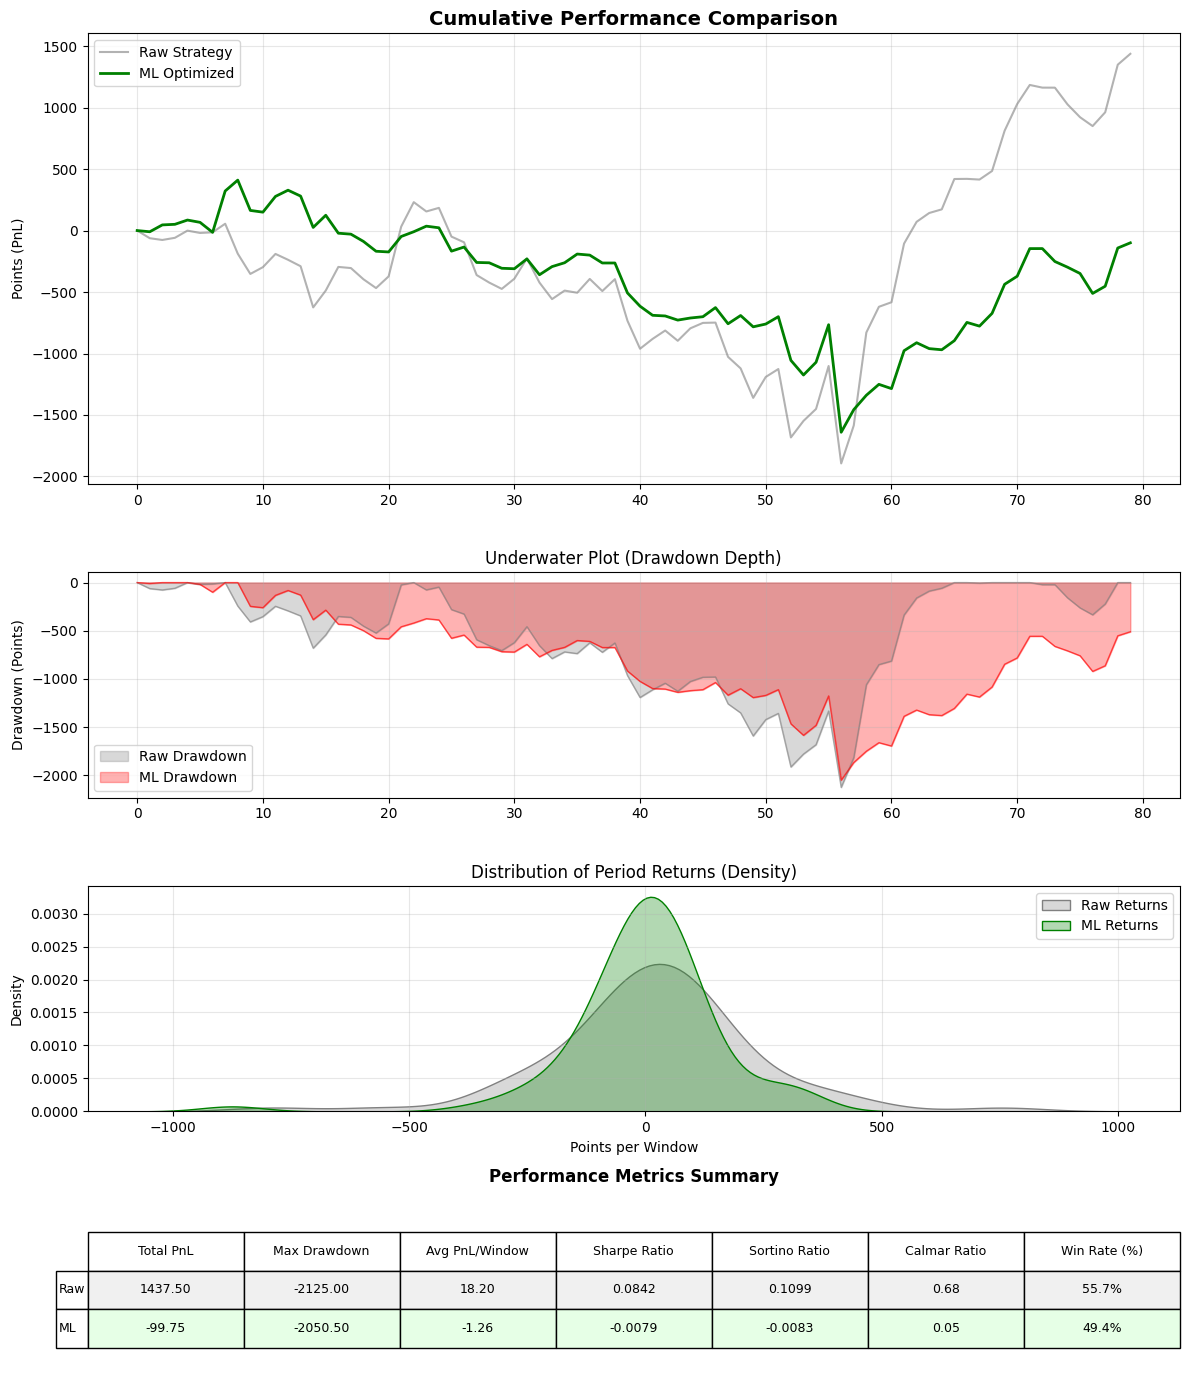

In [18]:
# --- CELL 1: ROBUST PERFORMANCE DASHBOARD (FULL VERSION) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_drawdown_series(equity_curve):
    """Oblicza serię drawdownów (obsunięć) w punktach."""
    series = pd.Series(equity_curve)
    running_max = series.cummax()
    drawdown = series - running_max
    return drawdown

def calculate_robust_metrics(equity_curve):
    equity = pd.Series(equity_curve)
    returns = equity.diff().dropna()
    
    total_pnl = equity.iloc[-1] - equity.iloc[0]
    avg_trade = returns.mean()
    
    dd_series = calculate_drawdown_series(equity)
    max_dd = dd_series.min() 
    
    std_dev = returns.std()
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() if len(downside_returns) > 0 else 1.0
    
    sharpe = (returns.mean() / std_dev) if std_dev != 0 else 0
    sortino = (returns.mean() / downside_std) if downside_std != 0 else 0
    calmar = abs(total_pnl / max_dd) if max_dd != 0 else 0
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total PnL": f"{total_pnl:.2f}",
        "Max Drawdown": f"{max_dd:.2f}",
        "Avg PnL/Window": f"{avg_trade:.2f}",
        "Sharpe Ratio": f"{sharpe:.4f}",
        "Sortino Ratio": f"{sortino:.4f}",
        "Calmar Ratio": f"{calmar:.2f}",
        "Win Rate (%)": f"{win_rate:.1f}%"
    }

def plot_performance_dashboard(eq_raw, eq_ml):
    # Obliczamy zwroty lokalnie dla histogramu
    returns_raw = pd.Series(eq_raw).diff().dropna()
    returns_ml = pd.Series(eq_ml).diff().dropna()

    # Setup Grid (4 wiersze: Equity, Drawdown, Histogram, Tabela)
    fig = plt.figure(figsize=(12, 14))
    gs = fig.add_gridspec(4, 1, height_ratios=[2, 1, 1, 0.8])
    
    # 1. EQUITY CURVE
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(eq_raw, label='Raw Strategy', color='gray', alpha=0.6)
    ax1.plot(eq_ml, label='ML Optimized', color='green', linewidth=2)
    ax1.set_title('Cumulative Performance Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Points (PnL)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # 2. DRAWDOWN
    dd_raw = calculate_drawdown_series(eq_raw)
    dd_ml = calculate_drawdown_series(eq_ml)
    
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(range(len(dd_raw)), dd_raw, 0, color='gray', alpha=0.3, label='Raw Drawdown')
    ax2.plot(dd_raw, color='gray', alpha=0.6, linewidth=1)
    
    ax2.fill_between(range(len(dd_ml)), dd_ml, 0, color='red', alpha=0.3, label='ML Drawdown')
    ax2.plot(dd_ml, color='red', alpha=0.6, linewidth=1)
    
    ax2.set_title('Underwater Plot (Drawdown Depth)', fontsize=12)
    ax2.set_ylabel('Drawdown (Points)')
    ax2.legend(loc='lower left')
    ax2.grid(True, alpha=0.3)

    # 3. HISTOGRAM ZWROTÓW (Distribution of Returns)
    ax3 = fig.add_subplot(gs[2])
    sns.kdeplot(returns_raw, ax=ax3, label='Raw Returns', color='gray', fill=True, alpha=0.3)
    sns.kdeplot(returns_ml, ax=ax3, label='ML Returns', color='green', fill=True, alpha=0.3)
    ax3.set_title('Distribution of Period Returns (Density)', fontsize=12)
    ax3.set_xlabel('Points per Window')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. METRICS TABLE
    m_raw = calculate_robust_metrics(eq_raw)
    m_ml = calculate_robust_metrics(eq_ml)
    
    ax4 = fig.add_subplot(gs[3])
    ax4.axis('off')
    col_labels = list(m_raw.keys())
    cell_text = [
        [f"{v}" for v in m_raw.values()],
        [f"{v}" for v in m_ml.values()]
    ]
    
    # Kolorowanie tabeli
    colors = [['#f0f0f0']*len(col_labels), ['#e6ffe6']*len(col_labels)]
    
    table = ax4.table(cellText=cell_text, colLabels=col_labels, 
                      rowLabels=['Raw', 'ML'], 
                      cellColours=colors,
                      loc='center', cellLoc='center')
    table.scale(1, 2)
    table.set_fontsize(12)
    ax4.set_title('Performance Metrics Summary', y=1.05, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# URUCHOMIENIE
if 'eq_raw' in locals() and 'eq_ml' in locals():
    plot_performance_dashboard(eq_raw, eq_ml)
else:
    print("Brak danych eq_raw/eq_ml.")

### 6.2 Time of the Day Analysis

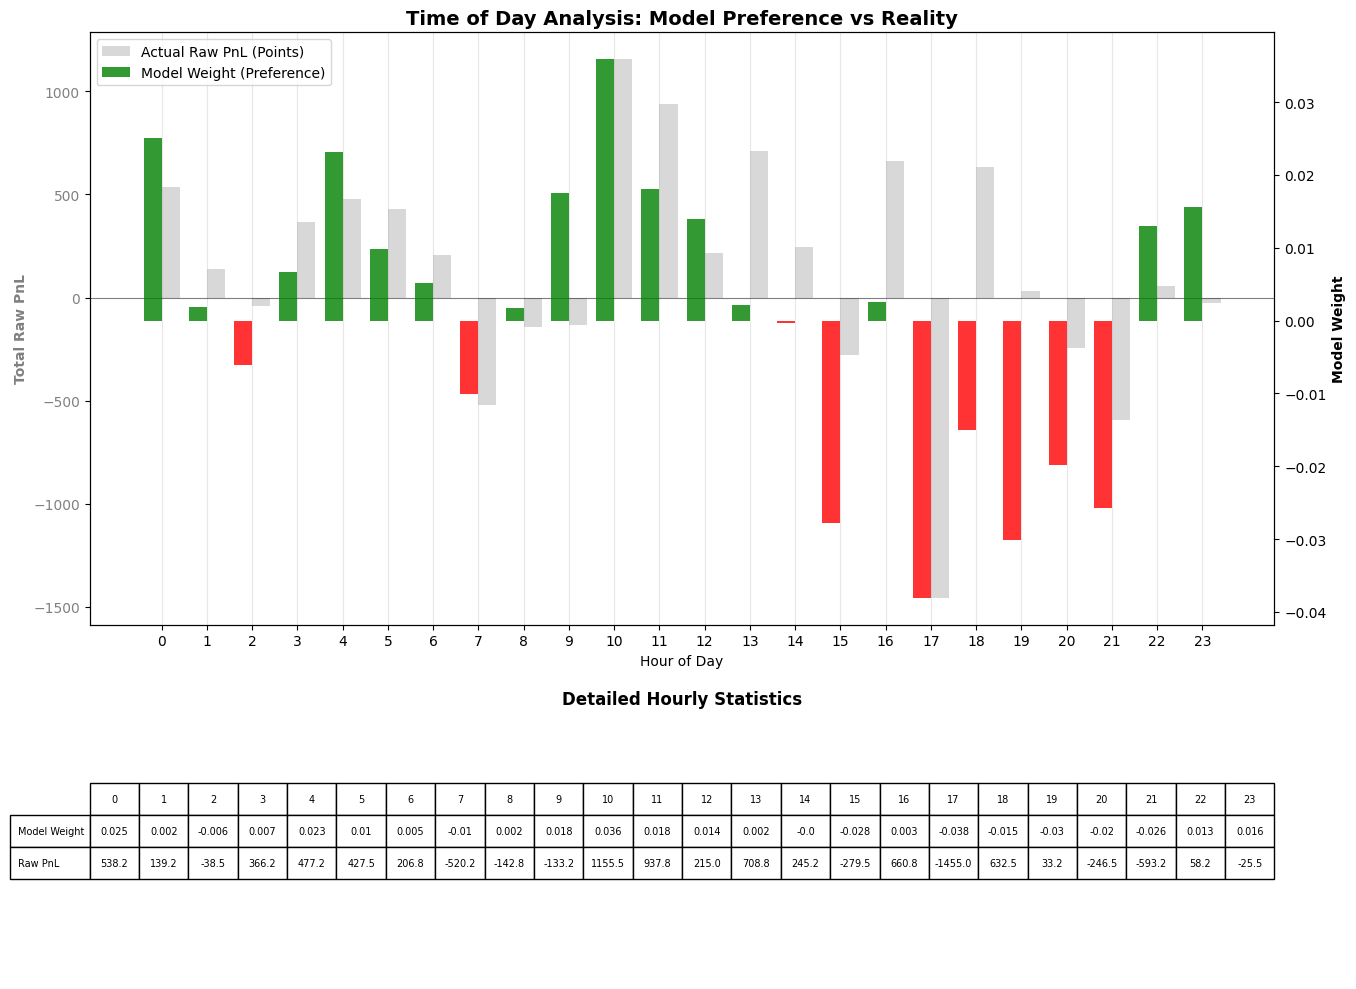

In [19]:
# --- CELL 2: TIME OF DAY ANALYSIS (CHART + TABLE) ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def analyze_hourly_bias(df):
    """Analizuje wagi modelu i rzeczywisty PnL dla godzin."""
    features = [c for c in df.columns if c not in ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']]
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])
    y = df['target']
    
    model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
    model.fit(X, y)
    
    coefs = []
    hours = []
    
    # Odtwarzamy prawdziwą godzinę
    df['real_hour'] = df['datetime'].dt.hour
    raw_pnl_by_hour = df.groupby('real_hour')['pnl'].sum()
    
    for col in features:
        if col.startswith('hour_'):
            h = int(col.split('_')[1])
            idx = features.index(col)
            weight = model.coef_[0][idx]
            hours.append(h)
            coefs.append(weight)
            
    res = pd.DataFrame({'Hour': hours, 'Model Weight': coefs})
    res = res.sort_values('Hour')
    res['Raw PnL'] = res['Hour'].map(raw_pnl_by_hour).fillna(0)
    
    return res

def plot_hourly_analysis_detailed(dataset):
    # Analiza danych
    hour_stats = analyze_hourly_bias(dataset)
    
    # Setup Wykresu (Wykres na górze, tabela na dole)
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1]) # Wykres 2x wyższy niż tabela
    
    # --- 1. WYKRES (DUAL AXIS) ---
    ax1 = fig.add_subplot(gs[0])
    width = 0.4
    x = hour_stats['Hour']
    
    # Oś lewa (PnL - Szare)
    bars_pnl = ax1.bar(x + width/2, hour_stats['Raw PnL'], width, label='Actual Raw PnL (Points)', color='gray', alpha=0.3)
    ax1.set_ylabel('Total Raw PnL', color='gray', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='gray')
    ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    
    # Oś prawa (Wagi - Kolorowe)
    ax2 = ax1.twinx()
    colors = ['green' if w > 0 else 'red' for w in hour_stats['Model Weight']]
    bars_w = ax2.bar(x - width/2, hour_stats['Model Weight'], width, label='Model Weight (Preference)', color=colors, alpha=0.8)
    ax2.set_ylabel('Model Weight', color='black', fontweight='bold')
    
    # Oś X
    ax1.set_xlabel('Hour of Day')
    ax1.set_xticks(x)
    ax1.set_title('Time of Day Analysis: Model Preference vs Reality', fontsize=14, fontweight='bold')
    
    # --- POPRAWIONA LEGENDA (Łączona) ---
    # Pobieramy uchwyty (handles) i etykiety z obu osi
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    # Rysujemy jedną legendę na osi ax1
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
    ax1.grid(True, axis='x', alpha=0.3)

    # --- 2. TABELA DANYCH ---
    ax_table = fig.add_subplot(gs[1])
    ax_table.axis('off')
    
    # Formatowanie danych do tabeli
    table_data = hour_stats.copy()
    table_data['Raw PnL'] = table_data['Raw PnL'].round(1)
    table_data['Model Weight'] = table_data['Model Weight'].round(3)
    
    # Transpozycja, żeby godziny były nagłówkami (czytelniej dla długiego szeregu)
    # Wybieramy tylko godziny, które mają dane
    table_data = table_data.set_index('Hour').T
    
    the_table = ax_table.table(cellText=table_data.values,
                               rowLabels=table_data.index,
                               colLabels=table_data.columns,
                               loc='center', cellLoc='center')
    
    the_table.scale(1, 1.5)
    the_table.set_fontsize(10)
    ax_table.set_title("Detailed Hourly Statistics", y=0.9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# URUCHOMIENIE
if 'ml_dataset' in locals():
    plot_hourly_analysis_detailed(ml_dataset)
else:
    print("Brak ml_dataset.")

## 7. Grid Search for Cross Validation Optimization

Starting Ultra-High-Res Grid Search on 144 combinations...
To potrwa dłuższą chwilę... Obserwuj licznik postępu.
[1/144] Window=1000, Step=100... 
--- STARTING OPTIMIZED WALK-FORWARD ANALYSIS ---
Window 0: Best Threshold=0.50 | ML PnL=-25.8
Window 1000: Best Threshold=0.50 | ML PnL=0.0
Window 2000: Best Threshold=0.58 | ML PnL=23.0
Window 3000: Best Threshold=0.50 | ML PnL=-43.8
Window 4000: Best Threshold=0.50 | ML PnL=16.0
Window 5000: Best Threshold=0.50 | ML PnL=-0.8
Window 6000: Best Threshold=0.51 | ML PnL=-25.8
Window 7000: Best Threshold=0.53 | ML PnL=-149.0
Window 8000: Best Threshold=0.58 | ML PnL=0.0
Window 9000: Best Threshold=0.54 | ML PnL=-39.0
Window 10000: Best Threshold=0.52 | ML PnL=-35.0
Window 11000: Best Threshold=0.51 | ML PnL=46.8
Window 12000: Best Threshold=0.50 | ML PnL=-30.0
Window 13000: Best Threshold=0.50 | ML PnL=-6.5
Window 14000: Best Threshold=0.56 | ML PnL=-12.5
Window 15000: Best Threshold=0.53 | ML PnL=-48.5
Window 16000: Best Threshold=0.51 | ML Pn

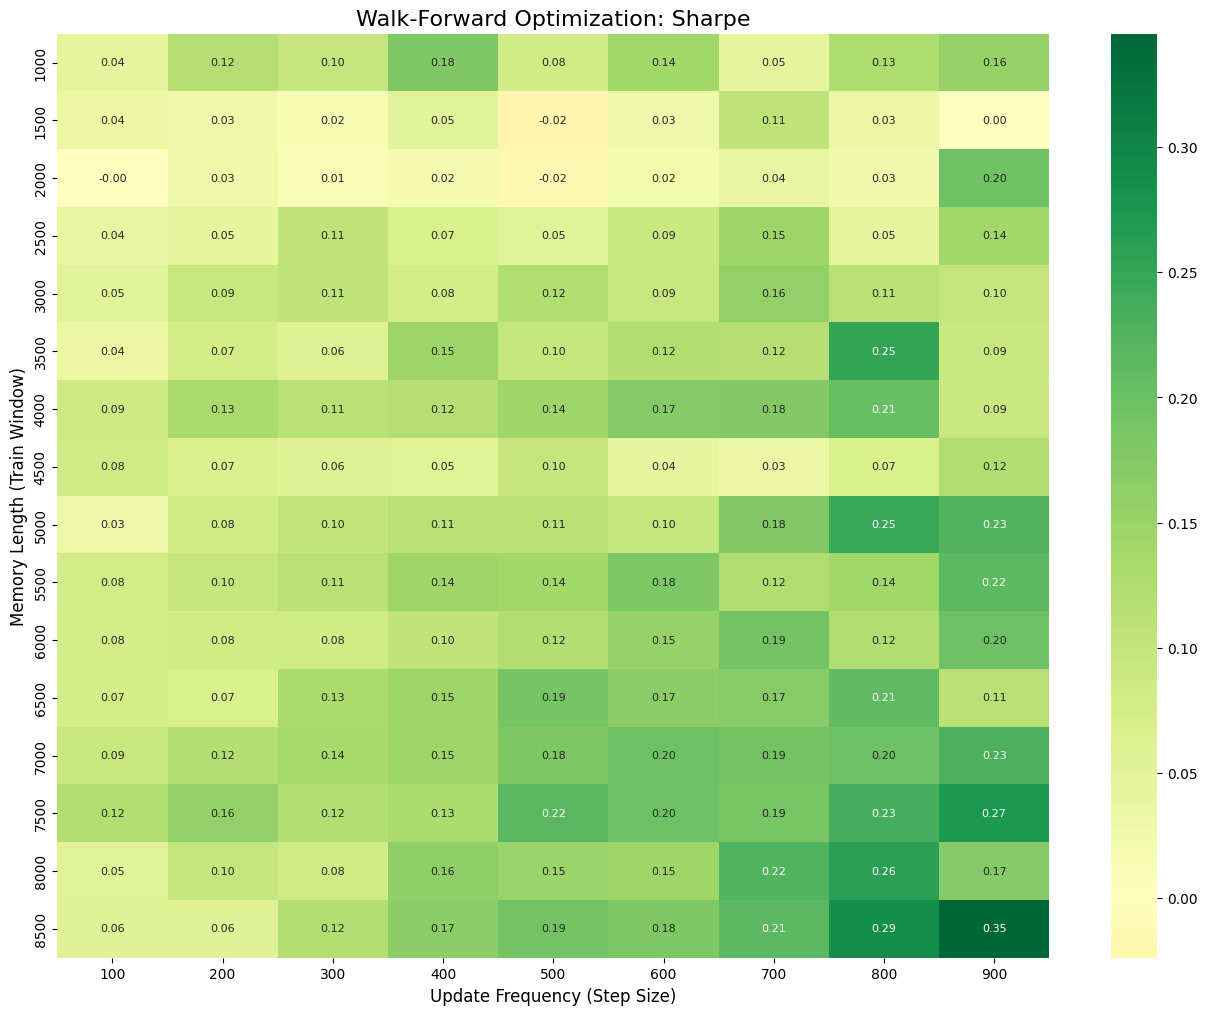

In [21]:
# --- CELL: ULTRA-HIGH RESOLUTION GRID SEARCH ---
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Funkcja pomocnicza do Sharpe
def calculate_quick_sharpe(equity_curve):
    equity = pd.Series(equity_curve)
    returns = equity.diff().dropna()
    if returns.std() == 0: return 0.0
    return returns.mean() / returns.std()

# 2. Główna pętla Grid Search
def run_grid_search_windows(df, train_windows, step_sizes):
    # Generujemy listę poprawnych par (Step nie może być większy niż Window)
    valid_combinations = [(w, s) for w in train_windows for s in step_sizes if s <= w]
    total = len(valid_combinations)
    
    print(f"Starting Ultra-High-Res Grid Search on {total} combinations...")
    print("To potrwa dłuższą chwilę... Obserwuj licznik postępu.")
    
    results = []
    
    for i, (w, s) in enumerate(valid_combinations, 1):
        # Wyświetlamy postęp
        print(f"[{i}/{total}] Window={w}, Step={s}...", end=" ")
        
        try:
            # Uruchamiamy symulację
            _, eq_ml, _ = run_rolling_cv_optimized(df, train_window=w, step=s)
            
            # Liczymy wynik
            sharpe = calculate_quick_sharpe(eq_ml)
            total_pnl = eq_ml[-1] - eq_ml[0]
            
            results.append({
                'Train Window': w,
                'Step Size': s,
                'Sharpe': sharpe,
                'Total PnL': total_pnl
            })
            print(f"-> Sharpe: {sharpe:.4f}")
            
        except Exception as e:
            print(f"Error: {e}")

    return pd.DataFrame(results)

# 3. Funkcja do rysowania dużej mapy ciepła
def plot_optimization_heatmap(results_df, metric='Sharpe'):
    if results_df.empty:
        print("Brak wyników.")
        return

    # Pivot table
    matrix = results_df.pivot(index='Train Window', columns='Step Size', values=metric)
    
    # Powiększamy wykres, bo siatka jest gęsta
    plt.figure(figsize=(16, 12))
    
    # Mapa ciepła z adnotacjami
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap='RdYlGn', center=0, 
                annot_kws={"size": 8}) # Mniejsza czcionka liczb, żeby się zmieściły
    
    plt.title(f'Walk-Forward Optimization: {metric}', fontsize=16)
    plt.xlabel('Update Frequency (Step Size)', fontsize=12)
    plt.ylabel('Memory Length (Train Window)', fontsize=12)
    plt.show()

# --- KONFIGURACJA SIATKI (ULTRA GĘSTA) ---

# Train Window: 1000, 1500, ..., 10000 (19 wartości)
windows_to_test = list(range(1000, 9000, 500))

# Step Size: 100, 200, ..., 1500 (15 wartości)
# To sprawdzi bardzo częste aktualizacje modelu
steps_to_test = list(range(100, 1000, 100))

# URUCHOMIENIE
if 'ml_dataset' in locals() and 'run_rolling_cv_optimized' in locals():
    # 1. Obliczenia
    opt_results = run_grid_search_windows(ml_dataset, windows_to_test, steps_to_test)
    
    if not opt_results.empty:
        # 2. Wyświetlenie TOP 5
        print("\n--- TOP 5 CONFIGURATIONS ---")
        print(opt_results.sort_values(by='Sharpe', ascending=False).head(5))
        
        # 3. Wizualizacja
        plot_optimization_heatmap(opt_results, metric='Sharpe')
    else:
        print("Brak wyników.")
else:
    print("BŁĄD: Uruchom najpierw celle definiujące model i dane.")

Running Experiment: Window=3500, Step=800...

--- STARTING OPTIMIZED WALK-FORWARD ANALYSIS ---
Window 0: Best Threshold=0.51 | ML PnL=-15.5
Window 4000: Best Threshold=0.52 | ML PnL=96.5
Window 8000: Best Threshold=0.50 | ML PnL=388.0
Window 12000: Best Threshold=0.52 | ML PnL=-168.0
Window 16000: Best Threshold=0.50 | ML PnL=15.2
Window 20000: Best Threshold=0.52 | ML PnL=54.0
Window 24000: Best Threshold=0.55 | ML PnL=29.8
Window 28000: Best Threshold=0.50 | ML PnL=43.0
Window 32000: Best Threshold=0.50 | ML PnL=170.0
Window 36000: Best Threshold=0.52 | ML PnL=-60.8

=== RETURN DISTRIBUTION STATISTICS ===
Mean Return:  42.5521
Std Dev:      169.1055
Skewness:     0.8709
Kurtosis:     2.4713
------------------------------
✅ Positive Skewness: Dobrze! Strategia ucina straty i pozwala zyskom rosnąć (ogon w prawo).
✅ Low Kurtosis: Wyniki są stabilne, brak szalonych wyskoków.

--- PERFORMANCE DASHBOARD ---


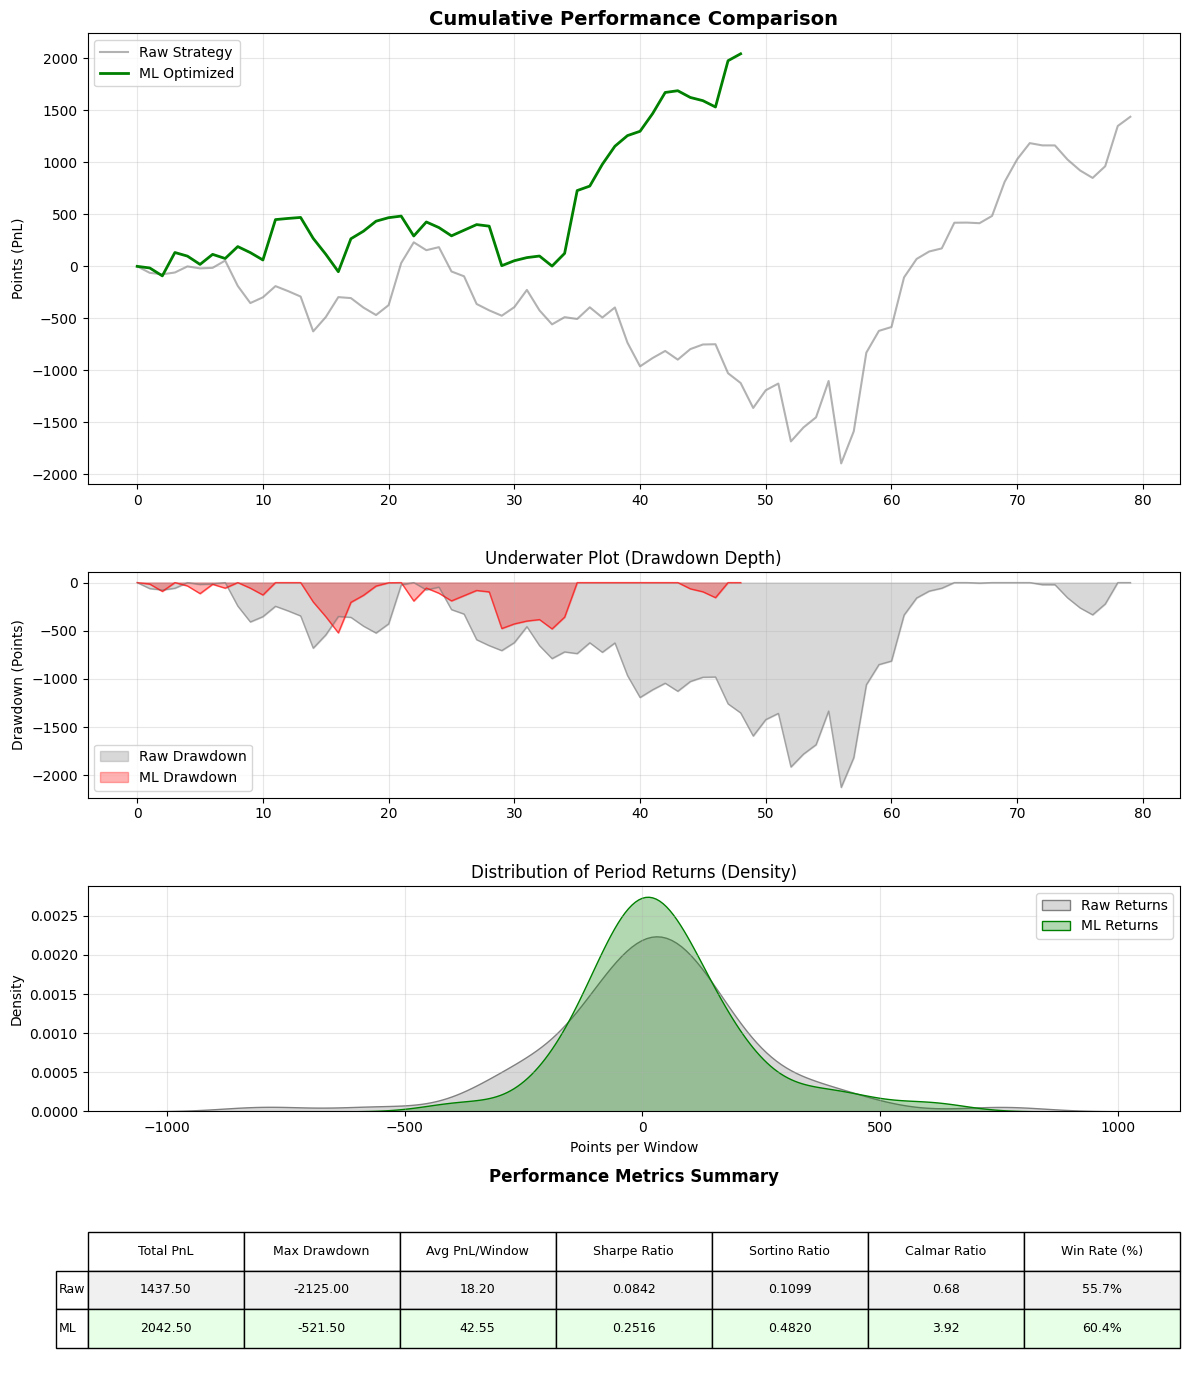


--- TIME OF DAY ANALYSIS ---


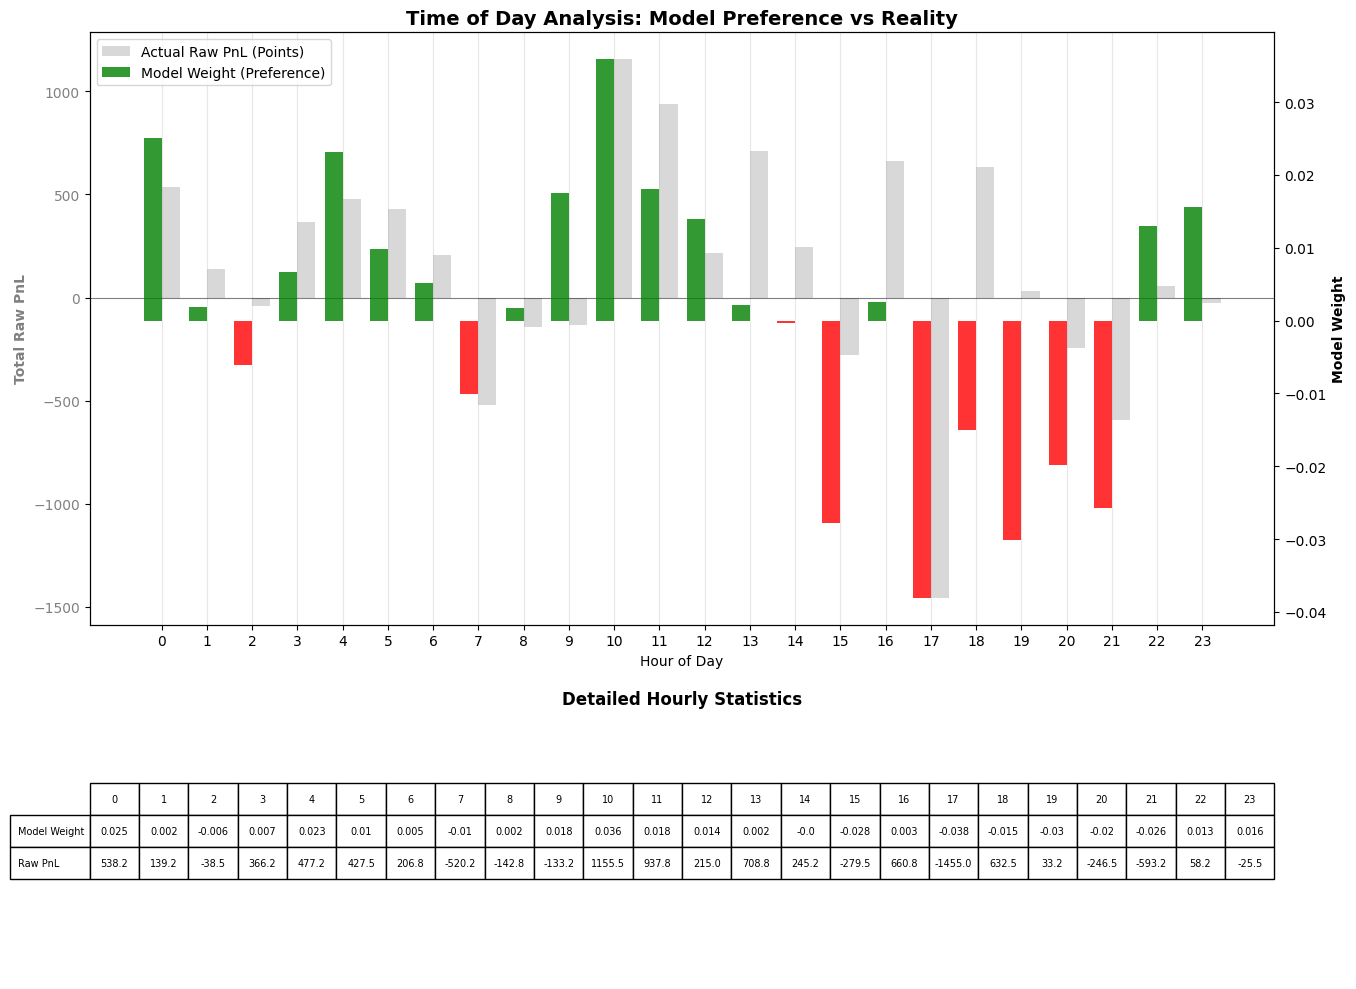

In [24]:
# --- CELL: EXPERIMENT (3500/800) + DISTRIBUTION ANALYSIS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# 1. Konfiguracja Eksperymentalna
EXPERIMENTAL_WINDOW = 3500
EXPERIMENTAL_STEP = 800

print(f"Running Experiment: Window={EXPERIMENTAL_WINDOW}, Step={EXPERIMENTAL_STEP}...")

# 2. Symulacja
_, eq_ml_experimental, _ = run_rolling_cv_optimized(ml_dataset, train_window=EXPERIMENTAL_WINDOW, step=EXPERIMENTAL_STEP)
eq_ml = eq_ml_experimental # Aktualizacja zmiennej dla dashboardów

# 3. Analiza Dystrybucji Zwrotów (Statystyka)
returns = pd.Series(eq_ml).diff().dropna()

print("\n=== RETURN DISTRIBUTION STATISTICS ===")
print(f"Mean Return:  {returns.mean():.4f}")
print(f"Std Dev:      {returns.std():.4f}")
print(f"Skewness:     {returns.skew():.4f}")
print(f"Kurtosis:     {returns.kurtosis():.4f}")

# Automatyczna interpretacja dla Ciebie
print("-" * 30)
if returns.skew() > 0:
    print("✅ Positive Skewness: Dobrze! Strategia ucina straty i pozwala zyskom rosnąć (ogon w prawo).")
elif returns.skew() < -0.5:
    print("⚠️ Negative Skewness: Uwaga! Ryzyko rzadkich, ale głębokich strat (ogon w lewo).")
else:
    print("ℹ️ Neutral Skewness: Rozkład zbliżony do symetrycznego.")

if returns.kurtosis() > 3:
    print("⚠️ High Kurtosis (Fat Tails): Występują ekstremalne wyniki częściej niż w rozkładzie normalnym.")
else:
    print("✅ Low Kurtosis: Wyniki są stabilne, brak szalonych wyskoków.")
print("=" * 30)

# 4. Wyświetlenie Dashboardów
print("\n--- PERFORMANCE DASHBOARD ---")
if 'plot_performance_dashboard' in locals():
    plot_performance_dashboard(eq_raw, eq_ml)

print("\n--- TIME OF DAY ANALYSIS ---")
if 'plot_hourly_analysis_detailed' in locals():
    plot_hourly_analysis_detailed(ml_dataset)

Running Simulation... Window=3500, Step=800

>>> REPORT: ORIGINAL (24H STRATEGY) <<<
Metric               | Value          
-----------------------------------
Total PnL            | 1746.00
Max Drawdown         | -883.50
Sharpe Ratio         | 0.0147
Sortino Ratio        | 0.0242
Calmar Ratio         | 1.98
Win Rate             | 42.60%
Active Trades        | 11728

>>> REPORT: FILTERED (NO NY SESSION) <<<
Metric               | Value          
-----------------------------------
Total PnL            | 1685.50
Max Drawdown         | -332.50
Sharpe Ratio         | 0.0274
Sortino Ratio        | 0.0393
Calmar Ratio         | 5.07
Win Rate             | 43.57%
Active Trades        | 6980

>>> REPORT: REJECTED (NY SESSION ONLY) <<<
Metric               | Value          
-----------------------------------
Total PnL            | 60.50
Max Drawdown         | -1822.00
Sharpe Ratio         | 0.0006
Sortino Ratio        | 0.0006
Calmar Ratio         | 0.03
Win Rate             | 41.18%
Active T

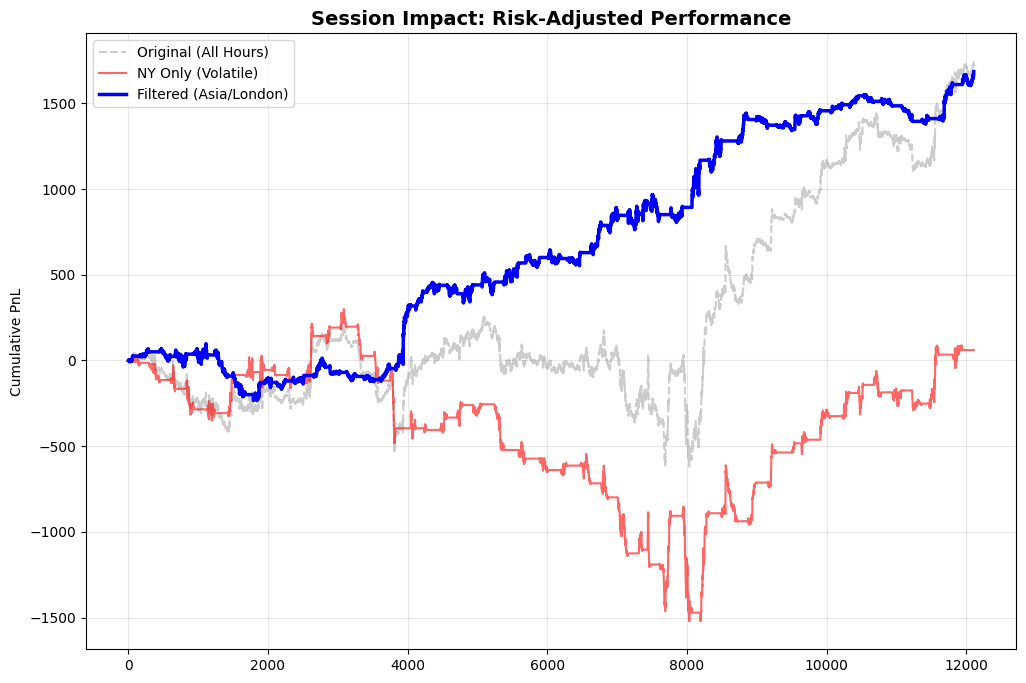


✅ SUCCESS: Strategia bez NY ma wyższe Sharpe Ratio (0.0274 vs 0.0147).
Mimo niższego PnL, jest lepsza inwestycyjnie (gładsza krzywa, mniejsze ryzyko).


In [32]:
# --- CELL: ADVANCED SESSION ANALYSIS WITH RISK METRICS (SHARPE & DD) ---
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. KONFIGURACJA (Wymuszamy parametry eksperymentalne)
ANALYSIS_WINDOW = 3500  
ANALYSIS_STEP = 800     
EXCLUDED_HOURS_NY = list(range(13, 23)) # NY Session Exclusion

def get_risk_metrics(equity_curve):
    """Oblicza zaawansowane metryki ryzyka."""
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    active_returns = returns[returns != 0] # Tylko aktywne okresy
    
    # Podstawy
    total_pnl = series.iloc[-1] - series.iloc[0]
    
    # Drawdown
    running_max = series.cummax()
    drawdown = series - running_max
    max_dd = drawdown.min()
    
    # Sharpe & Sortino (Uproszczone dla PnL punktowego)
    std_dev = returns.std()
    downside_std = returns[returns < 0].std()
    
    sharpe = (returns.mean() / std_dev) if std_dev != 0 else 0
    sortino = (returns.mean() / downside_std) if downside_std != 0 else 0
    calmar = abs(total_pnl / max_dd) if max_dd != 0 else 0
    
    return {
        'Total PnL': total_pnl,
        'Max Drawdown': max_dd,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Win Rate': (active_returns > 0).mean() * 100,
        'Num Trades': len(active_returns)
    }

def print_detailed_report(stats, name):
    print(f"\n>>> REPORT: {name.upper()} <<<")
    print(f"{'Metric':<20} | {'Value':<15}")
    print("-" * 35)
    print(f"{'Total PnL':<20} | {stats['Total PnL']:.2f}")
    print(f"{'Max Drawdown':<20} | {stats['Max Drawdown']:.2f}")
    print(f"{'Sharpe Ratio':<20} | {stats['Sharpe Ratio']:.4f}")
    print(f"{'Sortino Ratio':<20} | {stats['Sortino Ratio']:.4f}")
    print(f"{'Calmar Ratio':<20} | {stats['Calmar Ratio']:.2f}")
    print(f"{'Win Rate':<20} | {stats['Win Rate']:.2f}%")
    print(f"{'Active Trades':<20} | {stats['Num Trades']}")

def run_session_analysis_full(df, win, stp, excluded_hours):
    print(f"Running Simulation... Window={win}, Step={stp}")
    scaler = StandardScaler()
    model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)

    eq_full = [0]      # 24h
    eq_filtered = [0]  # No NY
    eq_rejected = [0]  # NY Only

    # Walk-Forward
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]

    for start in range(0, len(df) - win - stp, stp):
        train_df = df.iloc[start : start + win]
        test_df = df.iloc[start + win : start + win + stp].reset_index(drop=True)
        
        # Train
        X_train = scaler.fit_transform(train_df[features])
        y_train = train_df['target']
        model.fit(X_train, y_train)
        
        # Optimize
        probs_train = model.predict_proba(X_train)[:, 1]
        best_thr = 0.5
        best_pnl = -np.inf
        for thr in np.arange(0.5, 0.65, 0.02):
            mask = probs_train > thr
            s = train_df.loc[mask, 'pnl'].sum()
            if s > best_pnl:
                best_pnl = s
                best_thr = thr
        
        # Predict
        X_test = scaler.transform(test_df[features])
        probs_test = model.predict_proba(X_test)[:, 1]
        
        last_exit = -1
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            if row['entry_idx'] > last_exit:
                if probs_test[i] > best_thr:
                    pnl = row['pnl']
                    hour = row['datetime'].hour
                    
                    # 1. Full
                    eq_full.append(eq_full[-1] + pnl)
                    last_exit = row['exit_idx']
                    
                    # 2. Filter Logic
                    if hour in excluded_hours:
                        eq_filtered.append(eq_filtered[-1])
                        eq_rejected.append(eq_rejected[-1] + pnl)
                    else:
                        eq_filtered.append(eq_filtered[-1] + pnl)
                        eq_rejected.append(eq_rejected[-1])
                        
    return eq_full, eq_filtered, eq_rejected

# --- URUCHOMIENIE ---
if 'ml_dataset' in locals():
    eq_full, eq_no_ny, eq_only_ny = run_session_analysis_full(ml_dataset, ANALYSIS_WINDOW, ANALYSIS_STEP, EXCLUDED_HOURS_NY)
    
    stats_full = get_risk_metrics(eq_full)
    stats_no_ny = get_risk_metrics(eq_no_ny)
    stats_only_ny = get_risk_metrics(eq_only_ny)
    
    print("="*60)
    print_detailed_report(stats_full, "Original (24h Strategy)")
    print_detailed_report(stats_no_ny, "Filtered (No NY Session)")
    print_detailed_report(stats_only_ny, "Rejected (NY Session Only)")
    print("="*60)
    
    # Wykres
    plt.figure(figsize=(12, 8))
    plt.plot(eq_full, label='Original (All Hours)', color='gray', alpha=0.4, linestyle='--')
    plt.plot(eq_only_ny, label='NY Only (Volatile)', color='red', linewidth=1.5, alpha=0.6)
    plt.plot(eq_no_ny, label='Filtered (Asia/London)', color='blue', linewidth=2.5)
    plt.title('Session Impact: Risk-Adjusted Performance', fontsize=14, fontweight='bold')
    plt.ylabel('Cumulative PnL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # WNIOSEK AUTOMATYCZNY
    if stats_no_ny['Sharpe Ratio'] > stats_full['Sharpe Ratio']:
        print(f"\n✅ SUCCESS: Strategia bez NY ma wyższe Sharpe Ratio ({stats_no_ny['Sharpe Ratio']:.4f} vs {stats_full['Sharpe Ratio']:.4f}).")
        print("Mimo niższego PnL, jest lepsza inwestycyjnie (gładsza krzywa, mniejsze ryzyko).")
    else:
        print("\nℹ️ INFO: Oryginalna strategia ma wyższe Sharpe Ratio. Zmienność NY popłaca.")

else:
    print("Brak danych.")

# Random Forrest

In [35]:
# --- CELL 1: SETUP & LIBRARIES ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import time
import itertools

# --- INTEL ACCELERATOR CHECK ---
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("🚀 INTEL DETECTED: Intel® Extension for Scikit-learn enabled! (Turbo Mode On)")
except ImportError:
    print("ℹ️ Standard Scikit-learn mode. (To speed up on Intel: 'pip install scikit-learn-intelex')")

# Funkcja pomocnicza do metryk (żeby nie kopiować jej ciągle)
def get_risk_metrics(equity_curve):
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    active_returns = returns[returns != 0]
    total_pnl = series.iloc[-1] - series.iloc[0]
    running_max = series.cummax()
    max_dd = (series - running_max).min()
    std_dev = returns.std()
    sharpe = (returns.mean() / std_dev) if std_dev != 0 else 0
    return {
        'Total PnL': total_pnl, 'Max Drawdown': max_dd, 'Sharpe Ratio': sharpe,
        'Win Rate': (active_returns > 0).mean() * 100 if len(active_returns) > 0 else 0
    }

print("Setup Complete. Ready for Grid Search.")

🚀 INTEL DETECTED: Intel® Extension for Scikit-learn enabled! (Turbo Mode On)
Setup Complete. Ready for Grid Search.


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [43]:
# --- CELL 2: MASSIVE GRID SEARCH "UNLEASHED" + DETAILED REPORT ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
import time
import itertools

# Import paska postępu
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterator, **kwargs): return iterator

def run_total_rf_optimization(df):
    print("\n--- 🧠 STARTING MASSIVE GRID SEARCH 'UNLEASHED' (Aggressive Mode) ---")
    
    # 1. AGRESYWNA PRZESTRZEŃ POSZUKIWAŃ (160 kombinacji)
    
    # Pamięć: Skupiamy się na krótkiej/średniej + Test 1500
    windows = [1500, 2000, 2500, 3500, 5000]  
    
    # Częstotliwość: Standard
    steps = [600, 700, 800, 900]                  
    
    # Mózg: IDZIEMY GŁĘBOKO (do 24)
    depths = [16, 20, 24]                 
    
    # Precyzja: POZWALAMY NA RYZYKO (od 5)
    leafs = [10, 20, 30]                    
    
    combinations = list(itertools.product(windows, steps, depths, leafs))
    print(f"Testing {len(combinations)} combinations.")
    print("Cel: Znaleźć setup z wysokim PnL. Est. time: ~25-35 mins.\n")
    
    results = []
    start_time = time.time()
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    # Zakres progów (Szybki skan)
    thresholds_to_test = [0.51, 0.53, 0.55, 0.57, 0.59]
    
    # 2. PĘTLA
    for win, step, depth, leaf in tqdm(combinations, desc="Unleashed Search", unit="comb"):
        
        # 40 drzew do oceny
        model = RandomForestClassifier(n_estimators=40, max_depth=depth, 
                                       min_samples_leaf=leaf, random_state=42, n_jobs=-1)
        equity = [0]
        
        # Pętla Walk-Forward
        for start in range(0, len(df) - win - step, step):
            train_df = df.iloc[start : start + win]
            test_df = df.iloc[start + win : start + win + step]
            
            # A. Train
            model.fit(train_df[features], train_df['target'])
            
            # B. Szybki Thresholding
            probs_train = model.predict_proba(train_df[features])[:, 1]
            best_thr = 0.51
            best_train_pnl = -np.inf
            
            for thr in thresholds_to_test:
                mask = probs_train > thr
                if mask.sum() > 5:
                    pnl = train_df.loc[mask, 'pnl'].sum()
                    if pnl > best_train_pnl:
                        best_train_pnl = pnl
                        best_thr = thr
            
            # C. Test
            probs_test = model.predict_proba(test_df[features])[:, 1]
            mask_test = probs_test > best_thr
            equity.append(equity[-1] + test_df.loc[mask_test, 'pnl'].sum())
            
        # Ocena
        returns = pd.Series(equity).diff().dropna()
        if len(returns) > 0 and returns.std() > 0:
            sharpe = returns.mean() / returns.std()
        else:
            sharpe = 0
        
        results.append({'w': win, 's': step, 'd': depth, 'l': leaf, 'sharpe': sharpe, 'pnl': equity[-1]})

    # --- 3. RAPORT I ANALIZA WYNIKÓW ---
    df_res = pd.DataFrame(results)
    
    # Zwycięzca wg Sharpe (Bezpieczny wybór)
    best_sharpe = df_res.sort_values(by='sharpe', ascending=False).iloc[0]
    
    # Zwycięzca wg PnL (Agresywny wybór)
    best_pnl = df_res.sort_values(by='pnl', ascending=False).iloc[0]
    
    print("\n" + "="*60)
    print(f"🏆 SEARCH FINISHED in {(time.time()-start_time)/60:.1f} min")
    print("="*60)
    
    print("\n💎 BEST SHARPE CONFIG (Stability):")
    print(f"Params: Window={int(best_sharpe['w'])}, Step={int(best_sharpe['s'])}, Depth={int(best_sharpe['d'])}, Leaf={int(best_sharpe['l'])}")
    print(f"Score:  Sharpe={best_sharpe['sharpe']:.4f} | PnL={best_sharpe['pnl']:.0f}")

    print("\n💰 BEST PNL CONFIG (Profit):")
    print(f"Params: Window={int(best_pnl['w'])}, Step={int(best_pnl['s'])}, Depth={int(best_pnl['d'])}, Leaf={int(best_pnl['l'])}")
    print(f"Score:  Sharpe={best_pnl['sharpe']:.4f} | PnL={best_pnl['pnl']:.0f}")

    print("\n" + "-"*30)
    print("📊 TOP 10 BY SHARPE RATIO:")
    print("-" * 30)
    print(df_res.sort_values(by='sharpe', ascending=False).head(10)[['w','s','d','l','sharpe','pnl']].to_string(index=False))

    print("\n" + "-"*30)
    print("📊 TOP 10 BY TOTAL PNL:")
    print("-" * 30)
    print(df_res.sort_values(by='pnl', ascending=False).head(10)[['w','s','d','l','sharpe','pnl']].to_string(index=False))
    
    # Zwracamy parametry najlepszego Sharpe'a (domyślnie), ale w konsoli widzisz też PnL
    return int(best_sharpe['w']), int(best_sharpe['s']), int(best_sharpe['d']), int(best_sharpe['l'])

# --- URUCHOMIENIE ---
if 'ml_dataset' in locals():
    BEST_W, BEST_S, BEST_D, BEST_L = run_total_rf_optimization(ml_dataset)
else:
    print("Brak danych ml_dataset.")


--- 🧠 STARTING MASSIVE GRID SEARCH 'UNLEASHED' (Aggressive Mode) ---
Testing 180 combinations.
Cel: Znaleźć setup z wysokim PnL. Est. time: ~25-35 mins.



Unleashed Search: 100%|██████████| 180/180 [25:00<00:00,  8.34s/comb]


🏆 SEARCH FINISHED in 25.0 min

💎 BEST SHARPE CONFIG (Stability):
Params: Window=5000, Step=600, Depth=16, Leaf=30
Score:  Sharpe=0.3777 | PnL=916

💰 BEST PNL CONFIG (Profit):
Params: Window=2000, Step=800, Depth=20, Leaf=20
Score:  Sharpe=0.3361 | PnL=1161

------------------------------
📊 TOP 10 BY SHARPE RATIO:
------------------------------
   w   s  d  l   sharpe     pnl
5000 600 16 30 0.377704  916.00
2000 800 20 20 0.336122 1160.75
2000 800 24 20 0.319253 1126.75
2000 900 16 30 0.299260  846.75
5000 800 24 30 0.290192  576.25
2000 900 24 30 0.282380  767.50
5000 900 16 30 0.273705  580.25
2000 900 20 30 0.265584  729.75
5000 600 24 30 0.263648  550.25
2000 800 16 20 0.259471 1016.50

------------------------------
📊 TOP 10 BY TOTAL PNL:
------------------------------
   w   s  d  l   sharpe     pnl
2000 800 20 20 0.336122 1160.75
2000 800 24 20 0.319253 1126.75
2000 600 24 10 0.145157 1070.75
2500 900 24 10 0.242284 1053.00
1500 700 16 20 0.199875 1046.25
2500 600 24 10 0.171387


--- 🏁 RUNNING CHAMPION SIMULATION (Full Power 100 Trees) ---
Using Params: Window=5000, Step=600, Depth=16, Leaf=30


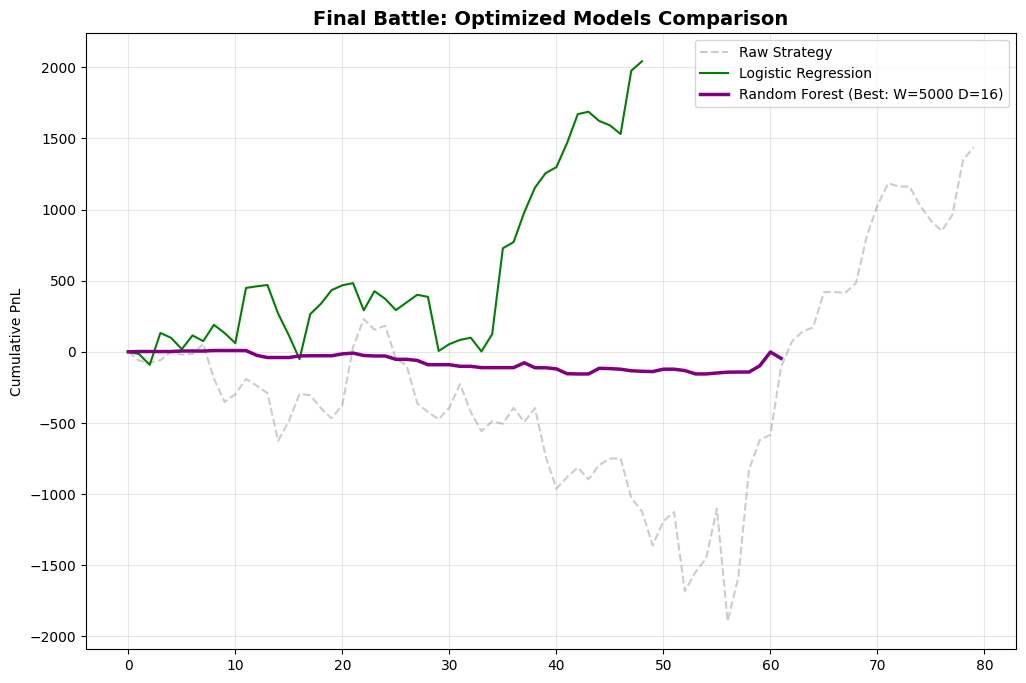

C:\Users\Robert\AppData\Local\Temp\ipykernel_4840\3400263507.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top, palette='viridis')


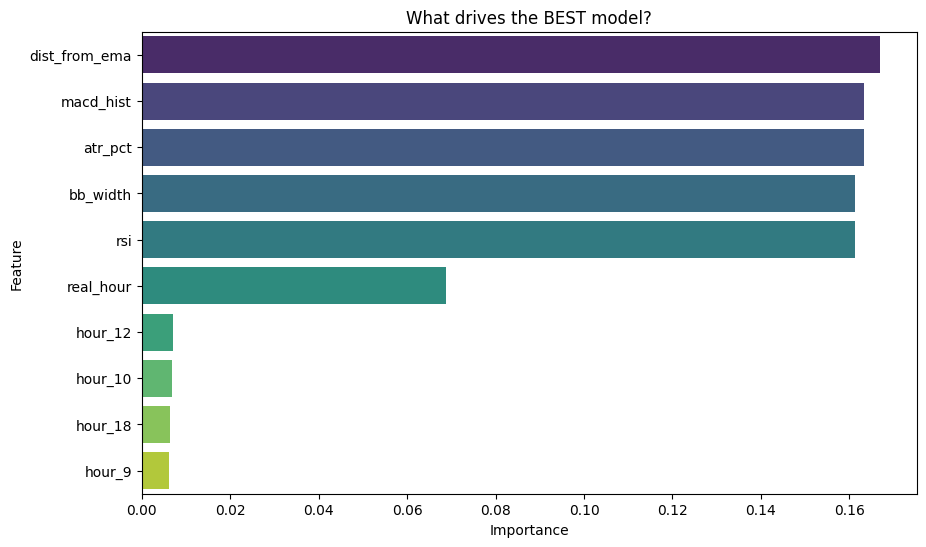


=== FINAL SCOREBOARD ===
                     Total PnL  Max Drawdown  Sharpe Ratio   Win Rate
Random Forest            -46.0       -164.75     -0.038154  39.473684
Logistic Regression     2042.5       -521.50      0.251630  60.416667
Raw Strategy            1437.5      -2125.00      0.084208  55.696203


In [44]:
# --- CELL 3: FINAL SIMULATION & PLOTTING ---

def run_final_champion_simulation(df, w, s, d, l):
    print(f"\n--- 🏁 RUNNING CHAMPION SIMULATION (Full Power 100 Trees) ---")
    print(f"Using Params: Window={w}, Step={s}, Depth={d}, Leaf={l}")
    
    # PEŁNA MOC: 100 drzew
    model = RandomForestClassifier(n_estimators=100, max_depth=d, min_samples_leaf=l, random_state=42, n_jobs=-1)
    
    equity_curve = [0]
    feat_importances = []
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    for start in range(0, len(df) - w - s, s):
        train_df = df.iloc[start : start + w]
        test_df = df.iloc[start + w : start + w + s].reset_index(drop=True)
        
        # 1. Train
        model.fit(train_df[features], train_df['target'])
        feat_importances.append(model.feature_importances_)
        
        # 2. Threshold Optimization (Dokładne szukanie progu)
        probs_train = model.predict_proba(train_df[features])[:, 1]
        best_thr = 0.51
        best_pnl = -np.inf
        
        for thr in np.arange(0.51, 0.65, 0.01):
            mask = probs_train > thr
            if mask.sum() > 5:
                s_pnl = train_df.loc[mask, 'pnl'].sum()
                if s_pnl > best_pnl: best_pnl = s_pnl; best_thr = thr
        
        # 3. Trade
        probs_test = model.predict_proba(test_df[features])[:, 1]
        last_exit = -1
        pnl_period = 0
        
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            if row['entry_idx'] > last_exit:
                if probs_test[i] > best_thr:
                    pnl_period += row['pnl']
                    last_exit = row['exit_idx']
                    
        equity_curve.append(equity_curve[-1] + pnl_period)
        
    return equity_curve, pd.DataFrame({'Feature': features, 'Importance': np.mean(feat_importances, axis=0)})

# --- URUCHOMIENIE ---
if 'BEST_W' in locals() and 'ml_dataset' in locals():
    # 1. Uruchomienie symulacji na zwycięzcy
    eq_rf, feat_importance = run_final_champion_simulation(ml_dataset, BEST_W, BEST_S, BEST_D, BEST_L)
    
    # 2. Wykres
    plt.figure(figsize=(12, 8))
    # Upewnij się, że eq_raw i eq_ml są w pamięci z poprzednich etapów notebooka
    if 'eq_raw' in locals(): plt.plot(eq_raw, label='Raw Strategy', color='gray', alpha=0.4, linestyle='--')
    if 'eq_ml' in locals(): plt.plot(eq_ml, label='Logistic Regression', color='green', linewidth=1.5)
    plt.plot(eq_rf, label=f'Random Forest (Best: W={BEST_W} D={BEST_D})', color='purple', linewidth=2.5)
    
    plt.title('Final Battle: Optimized Models Comparison', fontsize=14, fontweight='bold')
    plt.ylabel('Cumulative PnL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 3. Feature Importance
    plt.figure(figsize=(10, 6))
    top = feat_importance.sort_values(by='Importance', ascending=False).head(10)
    sns.barplot(x='Importance', y='Feature', data=top, palette='viridis')
    plt.title('What drives the BEST model?')
    plt.show()

    # 4. Scoreboard
    m_rf = get_risk_metrics(eq_rf)
    scores = {'Random Forest': m_rf}
    if 'eq_ml' in locals(): scores['Logistic Regression'] = get_risk_metrics(eq_ml)
    if 'eq_raw' in locals(): scores['Raw Strategy'] = get_risk_metrics(eq_raw)
    
    print("\n=== FINAL SCOREBOARD ===")
    print(pd.DataFrame(scores).T)
else:
    print("Najpierw uruchom Cell 2 (Grid Search)!")

--- 🔬 ETAP 1: PRECYZYJNE BADANIE PAMIĘCI (HIGH RES) ---
Skanowanie 63 punktów mapy pamięci...
Szukamy 'Zielonych Wysp' stabilności. To potrwa 15-25 min.


100%|██████████| 63/63 [13:19<00:00, 12.70s/comb]


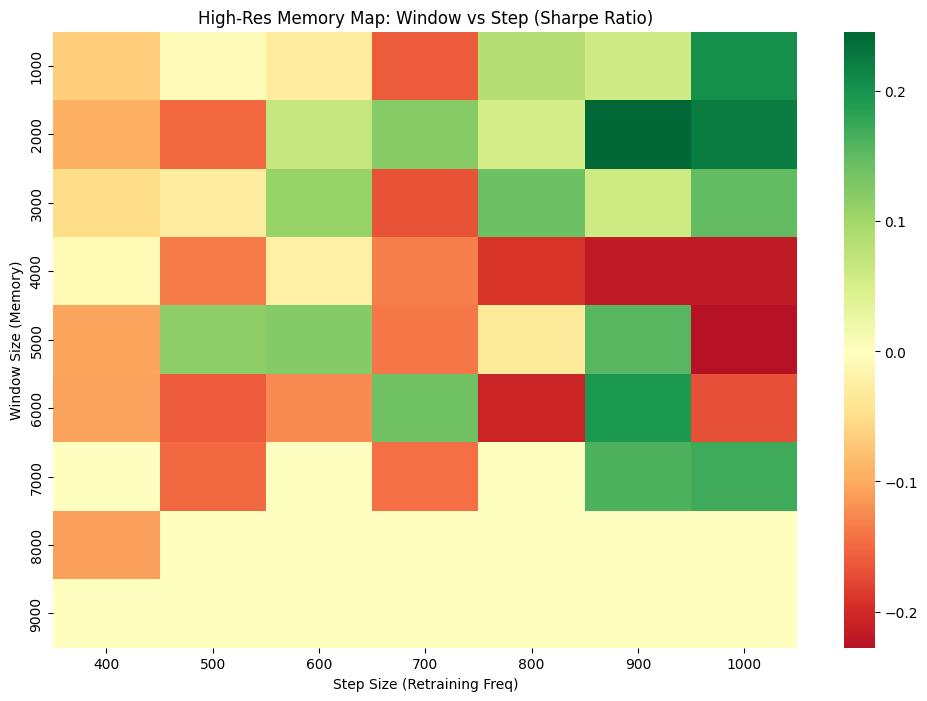


🔝 TOP 10 CONFIGURATIONS:
 Window  Step   Sharpe    PnL
   2000   900 0.245767 137.25
   2000  1000 0.224862  79.25
   1000  1000 0.204882 196.50
   6000   900 0.195398   2.50
   7000  1000 0.171499   0.25
   7000   900 0.162221   8.00
   5000   900 0.156174  19.25
   3000  1000 0.148727  62.50
   3000   800 0.140645  34.50
   6000   700 0.140028   2.50

🏆 STATISTICAL WINNER: Window=2000, Step=900


In [47]:
# --- ETAP 1: ROBUST HIGH-RES MEMORY SCAN ---
# Cel: Znaleźć STABILNĄ strefę pamięci, a nie przypadkowy punkt.

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import itertools

def run_robust_memory_test(df):
    print("--- 🔬 ETAP 1: PRECYZYJNE BADANIE PAMIĘCI (HIGH RES) ---")
    
    # 1. GĘSTA SIATKA (Fine-Grained Grid)
    # Windows: 1000, 2000, 3000 ... 9000 (szeroki zakres)
    windows = list(range(1000, 9001, 1000))
    
    # Steps: 100, 200, 300 ... 1000 (bardzo gęsto)
    steps = list(range(400, 1001, 100))
    
    combinations = list(itertools.product(windows, steps))
    print(f"Skanowanie {len(combinations)} punktów mapy pamięci...")
    print("Szukamy 'Zielonych Wysp' stabilności. To potrwa 15-25 min.")
    
    # Stałe parametry modelu (Bezpieczny Standard, żeby nie wprowadzać szumu)
    FIXED_DEPTH = 8
    FIXED_LEAF = 50 
    
    results = []
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    # Używamy paska postępu
    for win, step in tqdm(combinations, unit="comb"):
        
        # 60 drzew wystarczy do oceny trendu (szybciej niż 100)
        model = RandomForestClassifier(n_estimators=60, 
                                       max_depth=FIXED_DEPTH, 
                                       min_samples_leaf=FIXED_LEAF, 
                                       random_state=42, n_jobs=-1)
        
        equity = [0]
        
        # PĘTLA SYMULACYJNA (REALISTYCZNA - bez sumowania sygnałów)
        for start in range(0, len(df) - win - step, step):
            train_df = df.iloc[start : start + win]
            test_df = df.iloc[start + win : start + win + step].reset_index(drop=True)
            
            model.fit(train_df[features], train_df['target'])
            
            # Predict
            probs = model.predict_proba(test_df[features])[:, 1]
            
            last_exit = -1
            pnl_period = 0
            
            # Próg stały 0.52 (żeby badać tylko wpływ Pamięci)
            for i in range(len(test_df)):
                row = test_df.iloc[i]
                if row['entry_idx'] > last_exit:
                    if probs[i] > 0.52:
                        pnl_period += row['pnl']
                        last_exit = row['exit_idx']
            
            equity.append(equity[-1] + pnl_period)
            
        # Metryki
        returns = pd.Series(equity).diff().dropna()
        if len(returns) > 0 and returns.std() > 0:
            sharpe = returns.mean() / returns.std()
        else:
            sharpe = 0
            
        results.append({
            'Window': win, 
            'Step': step, 
            'Sharpe': sharpe, 
            'PnL': equity[-1]
        })

    # --- WIZUALIZACJA ---
    df_res = pd.DataFrame(results)
    
    # 1. Heatmapa (Najważniejsza)
    pivot_sharpe = df_res.pivot(index='Window', columns='Step', values='Sharpe')
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_sharpe, annot=False, cmap='RdYlGn', center=0) # Annot=False bo za gęsto
    plt.title('High-Res Memory Map: Window vs Step (Sharpe Ratio)')
    plt.ylabel('Window Size (Memory)')
    plt.xlabel('Step Size (Retraining Freq)')
    plt.show()
    
    # 2. Top 10 Wyników
    print("\n🔝 TOP 10 CONFIGURATIONS:")
    print(df_res.sort_values(by='Sharpe', ascending=False).head(10).to_string(index=False))
    
    # 3. Wybór Zwycięzcy (ale patrz na heatmapę!)
    best = df_res.sort_values(by='Sharpe', ascending=False).iloc[0]
    print(f"\n🏆 STATISTICAL WINNER: Window={int(best['Window'])}, Step={int(best['Step'])}")
    
    return int(best['Window']), int(best['Step'])

# --- URUCHOMIENIE ---
if 'ml_dataset' in locals():
    RF_WIN, RF_STEP = run_robust_memory_test(ml_dataset)
else:
    print("Brak danych.")

--- 🔬 ETAP 1.5: ZOOM NA STREFĘ 2000/900 ---
Skanowanie 42 punktów w strefie stabilności...
Szukamy najjaśniejszego punktu. Est. czas: ~5-8 min.


100%|██████████| 42/42 [06:09<00:00,  8.80s/comb]


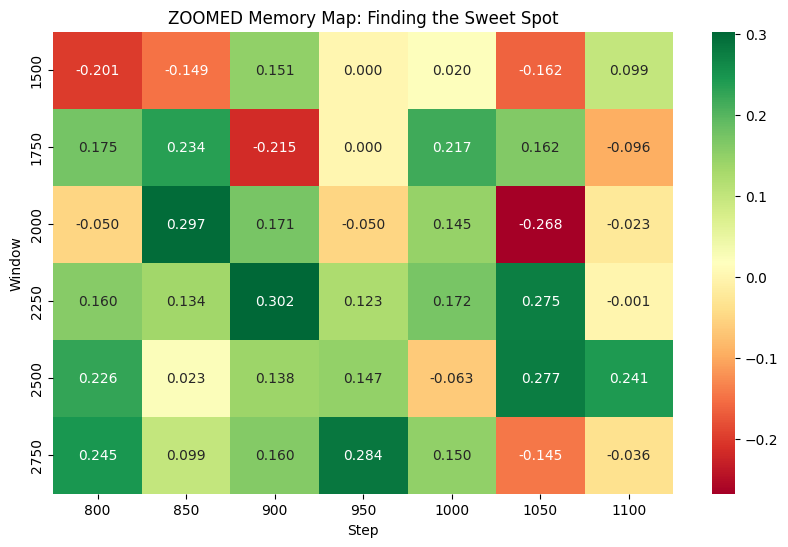


🏆 LOCAL WINNER: Window=2250, Step=900
Score: Sharpe=0.3024, PnL=170


In [48]:
# --- ETAP 1.5: ZOOM IN (MEMORY FINE TUNING) ---
# Cel: Precyzyjne namierzenie środka "Zielonej Wyspy" wokół 2000/900.

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import itertools

def run_memory_zoom(df):
    print("--- 🔬 ETAP 1.5: ZOOM NA STREFĘ 2000/900 ---")
    
    # 1. BARDZO GĘSTA SIATKA LOKALNA
    # Window: Sprawdzamy co 250 świec wokół 2000
    windows = [1500, 1750, 2000, 2250, 2500, 2750]
    
    # Step: Sprawdzamy co 50 świec wokół 900
    steps = [800, 850, 900, 950, 1000, 1050, 1100]
    
    combinations = list(itertools.product(windows, steps))
    print(f"Skanowanie {len(combinations)} punktów w strefie stabilności...")
    print("Szukamy najjaśniejszego punktu. Est. czas: ~5-8 min.")
    
    # Stałe parametry (nadal bezpieczne)
    FIXED_DEPTH = 8
    FIXED_LEAF = 50 
    
    results = []
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    for win, step in tqdm(combinations, unit="comb"):
        
        # 40 drzew dla balansu precyzji
        model = RandomForestClassifier(n_estimators=40, 
                                       max_depth=FIXED_DEPTH, 
                                       min_samples_leaf=FIXED_LEAF, 
                                       random_state=42, n_jobs=-1)
        
        equity = [0]
        
        # Pętla symulacyjna
        for start in range(0, len(df) - win - step, step):
            train_df = df.iloc[start : start + win]
            test_df = df.iloc[start + win : start + win + step].reset_index(drop=True)
            
            model.fit(train_df[features], train_df['target'])
            
            probs = model.predict_proba(test_df[features])[:, 1]
            last_exit = -1
            pnl_period = 0
            
            # Próg stały
            for i in range(len(test_df)):
                row = test_df.iloc[i]
                if row['entry_idx'] > last_exit:
                    if probs[i] > 0.52:
                        pnl_period += row['pnl']
                        last_exit = row['exit_idx']
            
            equity.append(equity[-1] + pnl_period)
            
        returns = pd.Series(equity).diff().dropna()
        if len(returns) > 0 and returns.std() > 0:
            sharpe = returns.mean() / returns.std()
        else:
            sharpe = 0
            
        results.append({'Window': win, 'Step': step, 'Sharpe': sharpe, 'PnL': equity[-1]})

    # --- WYNIKI ---
    df_res = pd.DataFrame(results)
    
    # Heatmapa (Zoomed)
    pivot_sharpe = df_res.pivot(index='Window', columns='Step', values='Sharpe')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_sharpe, annot=True, cmap='RdYlGn', fmt='.3f')
    plt.title('ZOOMED Memory Map: Finding the Sweet Spot')
    plt.show()
    
    # Zwycięzca
    best = df_res.sort_values(by='Sharpe', ascending=False).iloc[0]
    print(f"\n🏆 LOCAL WINNER: Window={int(best['Window'])}, Step={int(best['Step'])}")
    print(f"Score: Sharpe={best['Sharpe']:.4f}, PnL={best['PnL']:.0f}")
    
    return int(best['Window']), int(best['Step'])

# --- URUCHOMIENIE ---
if 'ml_dataset' in locals():
    RF_WIN, RF_STEP = run_memory_zoom(ml_dataset)
else:
    print("Brak danych.")

--- 🧠 ETAP 2: STROJENIE MÓZGU (Window=2250, Step=900) ---
Testowanie 36 konfiguracji struktury...
Szukamy wysokiego PnL przy zachowaniu Sharpe > 0.30.


100%|██████████| 36/36 [07:47<00:00, 12.98s/comb]


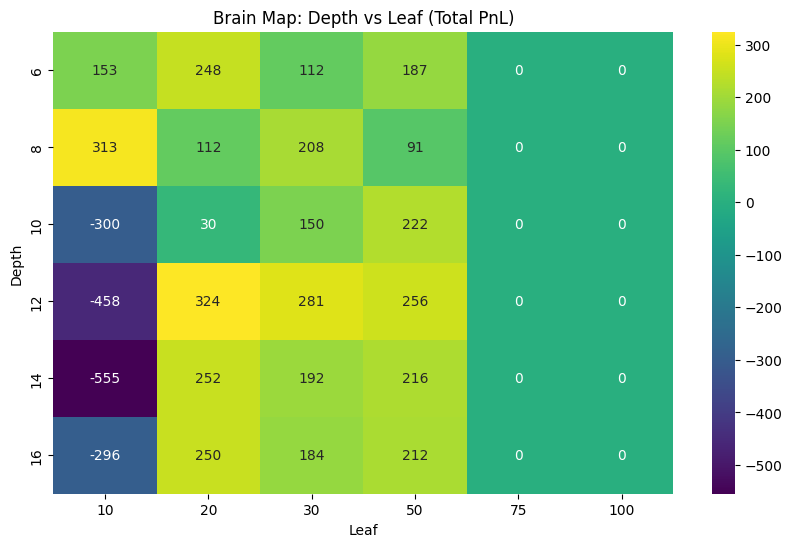


🔝 TOP 10 CONFIGURATIONS (By Stability/Sharpe):
 Depth  Leaf   Sharpe    PnL
    10    50 0.391932 222.25
    12    50 0.319331 256.50
     6    50 0.301567 186.75
     6    20 0.291508 248.00
    14    50 0.276075 216.00
    16    50 0.271152 212.25
    12    30 0.208364 281.25
    12    20 0.195394 324.50
     6    30 0.182148 112.50
     8    30 0.176023 208.00

💰 TOP 10 CONFIGURATIONS (By Profit/PnL):
 Depth  Leaf   Sharpe    PnL
    12    20 0.195394 324.50
     8    10 0.173428 312.75
    12    30 0.208364 281.25
    12    50 0.319331 256.50
    14    20 0.121632 251.50
    16    20 0.127581 250.25
     6    20 0.291508 248.00
    10    50 0.391932 222.25
    14    50 0.276075 216.00
    16    50 0.271152 212.25


In [49]:
# --- ETAP 2: OPTYMALIZACJA STRUKTURY (BRAIN SCAN) ---
# Cel: Znaleźć balans między geniuszem a szaleństwem na oknie 2250/900.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import itertools

# Ustawiamy parametry z Etapu 1 na sztywno
FIXED_WIN = 2250
FIXED_STEP = 900

def run_brain_scan(df):
    print(f"--- 🧠 ETAP 2: STROJENIE MÓZGU (Window={FIXED_WIN}, Step={FIXED_STEP}) ---")
    
    # 1. PRZESTRZEŃ POSZUKIWAŃ (STRUKTURA)
    
    # Głębokość: Od bezpiecznych (6) do agresywnych (16)
    # Nie idziemy w 24, bo widzieliśmy wcześniej, że to overfit.
    depths = [6, 8, 10, 12, 14, 16]
    
    # Liście: Od snajperskich (10) do bezpiecznych (100)
    leafs = [10, 20, 30, 50, 75, 100]
    
    combinations = list(itertools.product(depths, leafs))
    print(f"Testowanie {len(combinations)} konfiguracji struktury...")
    print("Szukamy wysokiego PnL przy zachowaniu Sharpe > 0.30.")
    
    results = []
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    # Używamy 60 drzew dla wiarygodności
    for depth, leaf in tqdm(combinations, unit="comb"):
        
        model = RandomForestClassifier(n_estimators=60, 
                                       max_depth=depth, 
                                       min_samples_leaf=leaf, 
                                       random_state=42, n_jobs=-1)
        
        equity = [0]
        
        # Pętla symulacyjna na ustalonym oknie
        for start in range(0, len(df) - FIXED_WIN - FIXED_STEP, FIXED_STEP):
            train_df = df.iloc[start : start + FIXED_WIN]
            test_df = df.iloc[start + FIXED_WIN : start + FIXED_WIN + FIXED_STEP].reset_index(drop=True)
            
            model.fit(train_df[features], train_df['target'])
            
            # Predict
            probs = model.predict_proba(test_df[features])[:, 1]
            last_exit = -1
            pnl_period = 0
            
            # Szybki dynamiczny thresholding (bo struktura wpływa na pewność modelu)
            # Sprawdzamy tylko 3 progi dla prędkości
            probs_train = model.predict_proba(train_df[features])[:, 1]
            best_thr = 0.52
            best_train_pnl = -np.inf
            for thr in [0.51, 0.53, 0.55]:
                mask = probs_train > thr
                if mask.sum() > 5:
                    tpnl = train_df.loc[mask, 'pnl'].sum()
                    if tpnl > best_train_pnl: best_train_pnl = tpnl; best_thr = thr
            
            # Trade
            for i in range(len(test_df)):
                row = test_df.iloc[i]
                if row['entry_idx'] > last_exit:
                    if probs[i] > best_thr:
                        pnl_period += row['pnl']
                        last_exit = row['exit_idx']
            
            equity.append(equity[-1] + pnl_period)
            
        # Metryki
        returns = pd.Series(equity).diff().dropna()
        if len(returns) > 0 and returns.std() > 0:
            sharpe = returns.mean() / returns.std()
        else:
            sharpe = 0
            
        results.append({
            'Depth': depth, 
            'Leaf': leaf, 
            'Sharpe': sharpe, 
            'PnL': equity[-1]
        })

    # --- WIZUALIZACJA ---
    df_res = pd.DataFrame(results)
    
    # 1. Heatmapa PnL (Tym razem patrzymy na ZYSK)
    pivot_pnl = df_res.pivot(index='Depth', columns='Leaf', values='PnL')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_pnl, annot=True, cmap='viridis', fmt='.0f')
    plt.title('Brain Map: Depth vs Leaf (Total PnL)')
    plt.show()
    
    # 2. Tabela wyników (Sortowana po Sharpe, ale pokazująca PnL)
    print("\n🔝 TOP 10 CONFIGURATIONS (By Stability/Sharpe):")
    print(df_res.sort_values(by='Sharpe', ascending=False).head(10).to_string(index=False))
    
    # 3. Tabela wyników (Sortowana po PnL - dla chciwych)
    print("\n💰 TOP 10 CONFIGURATIONS (By Profit/PnL):")
    print(df_res.sort_values(by='PnL', ascending=False).head(10).to_string(index=False))
    
    # Rekomendacja
    best_sharpe = df_res.sort_values(by='Sharpe', ascending=False).iloc[0]
    best_pnl = df_res.sort_values(by='PnL', ascending=False).iloc[0]
    
    return int(best_sharpe['Depth']), int(best_sharpe['Leaf']), int(best_pnl['Depth']), int(best_pnl['Leaf'])

# --- URUCHOMIENIE ---
if 'ml_dataset' in locals():
    RF_DEPTH_S, RF_LEAF_S, RF_DEPTH_P, RF_LEAF_P = run_brain_scan(ml_dataset)
else:
    print("Brak danych.")

--- 🌲 ETAP 3: TEST SIŁY LASU (Trees) ---
Konfiguracja: W=2250, S=900, D=10, L=50
Testowanie 5 wariantów...


100%|██████████| 5/5 [02:16<00:00, 27.21s/run]



🌲 WYNIKI TESTU DRZEW:
 Trees   Sharpe    PnL
    60 0.219107  92.50
   100 0.264073 122.00
   200 0.150756  30.75
   300 0.150756  27.50
   500 0.153238  47.00


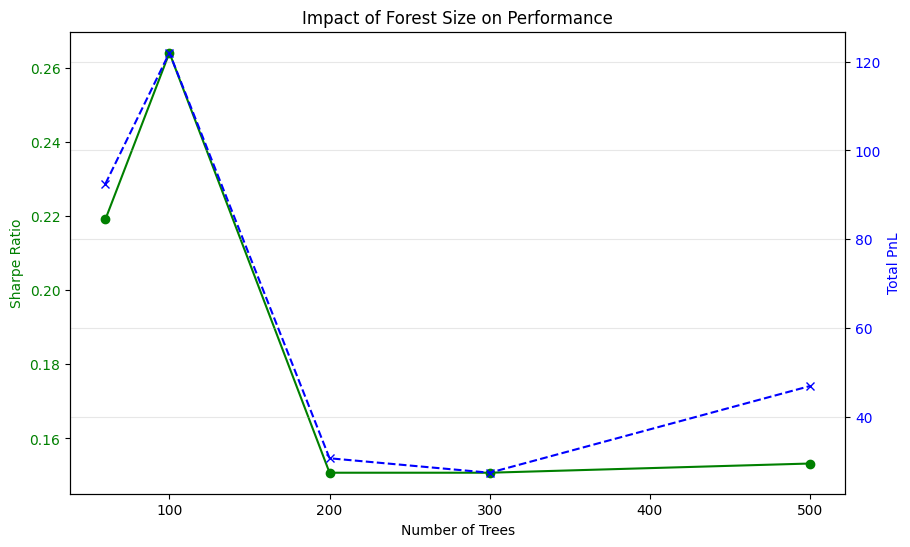


✅ FINAL CONFIGURATION READY: Trees=100


In [50]:
# --- ETAP 3: LICZBA DRZEW (N_ESTIMATORS) ---
# Cel: Wygładzenie krzywej kapitału. Sprawdzamy, czy więcej drzew = lepszy wynik.

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Parametry zwycięskie z Etapów 1 i 2
BEST_WIN = 2250
BEST_STEP = 900
BEST_DEPTH = 10
BEST_LEAF = 50

def run_trees_test(df):
    print(f"--- 🌲 ETAP 3: TEST SIŁY LASU (Trees) ---")
    print(f"Konfiguracja: W={BEST_WIN}, S={BEST_STEP}, D={BEST_DEPTH}, L={BEST_LEAF}")
    
    # Sprawdzamy liczbę drzew
    n_trees_list = [60, 100, 200, 300, 500]
    
    results = []
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    print(f"Testowanie {len(n_trees_list)} wariantów...")
    
    for n_trees in tqdm(n_trees_list, unit="run"):
        
        model = RandomForestClassifier(n_estimators=n_trees, 
                                       max_depth=BEST_DEPTH, 
                                       min_samples_leaf=BEST_LEAF, 
                                       random_state=42, n_jobs=-1)
        
        equity = [0]
        
        # Pętla symulacyjna
        for start in range(0, len(df) - BEST_WIN - BEST_STEP, BEST_STEP):
            train_df = df.iloc[start : start + BEST_WIN]
            test_df = df.iloc[start + BEST_WIN : start + BEST_WIN + BEST_STEP].reset_index(drop=True)
            
            model.fit(train_df[features], train_df['target'])
            
            probs = model.predict_proba(test_df[features])[:, 1]
            last_exit = -1
            pnl_period = 0
            
            # Szybki próg 0.52 (lub dynamiczny, tu stały dla porównania drzew)
            # W tym etapie chodzi o stabilność predykcji
            for i in range(len(test_df)):
                row = test_df.iloc[i]
                if row['entry_idx'] > last_exit:
                    if probs[i] > 0.52:
                        pnl_period += row['pnl']
                        last_exit = row['exit_idx']
            
            equity.append(equity[-1] + pnl_period)
            
        # Metryki
        returns = pd.Series(equity).diff().dropna()
        if len(returns) > 0 and returns.std() > 0:
            sharpe = returns.mean() / returns.std()
        else:
            sharpe = 0
            
        results.append({
            'Trees': n_trees, 
            'Sharpe': sharpe, 
            'PnL': equity[-1]
        })

    # --- WYNIKI ---
    df_res = pd.DataFrame(results)
    
    print("\n🌲 WYNIKI TESTU DRZEW:")
    print(df_res.to_string(index=False))
    
    # Wykres
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    ax1.set_xlabel('Number of Trees')
    ax1.set_ylabel('Sharpe Ratio', color='green')
    ax1.plot(df_res['Trees'], df_res['Sharpe'], color='green', marker='o', label='Sharpe')
    ax1.tick_params(axis='y', labelcolor='green')
    
    ax2 = ax1.twinx()
    ax2.set_ylabel('Total PnL', color='blue')
    ax2.plot(df_res['Trees'], df_res['PnL'], color='blue', marker='x', linestyle='--', label='PnL')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    plt.title('Impact of Forest Size on Performance')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Wybór najlepszego (najwyższe Sharpe)
    best = df_res.sort_values(by='Sharpe', ascending=False).iloc[0]
    return int(best['Trees'])

# --- URUCHOMIENIE ---
if 'ml_dataset' in locals():
    RF_TREES = run_trees_test(ml_dataset)
    print(f"\n✅ FINAL CONFIGURATION READY: Trees={RF_TREES}")
else:
    print("Brak danych.")

--- 🌲 RANDOM FOREST: FINAL SOLO RUN ---
Params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 50, 'random_state': 42, 'n_jobs': -1}
Memory: Window=2250, Step=900


Simulating: 100%|██████████| 44/44 [00:14<00:00,  2.93it/s]


🏆 RANDOM FOREST FINAL RESULTS
⏱️  Simulation Time: 0.3 min
Total PnL:      156.00
Sharpe Ratio:   0.2755
Max Drawdown:   -12.50
Total Trades:   54


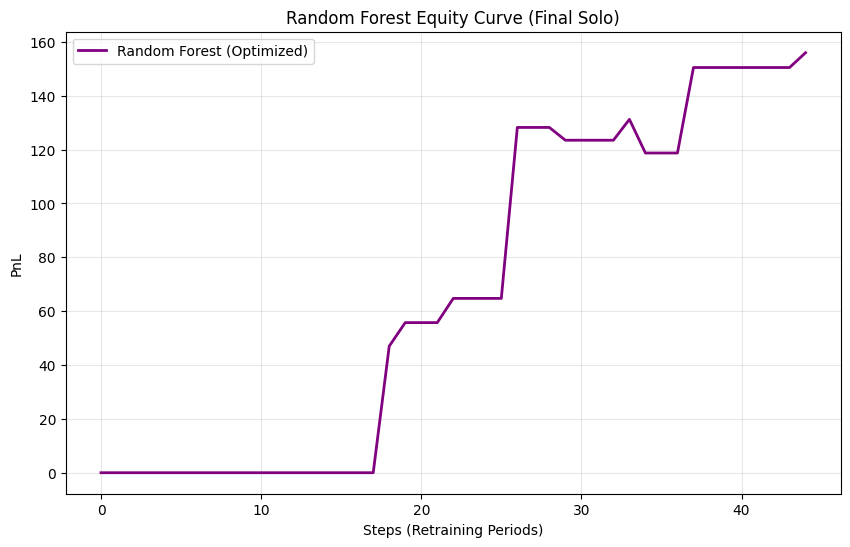

In [52]:
# --- CELL 4: FINAL SOLO RUN (OPTIMIZED RF) + TIME TRACKER ---
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. PARAMETRY ZWYCIĘSKIE (Z Twoich badań)
RF_FINAL_PARAMS = {
    'n_estimators': 100,      # Z Etapu 3
    'max_depth': 10,          # Z Etapu 2
    'min_samples_leaf': 50,   # Z Etapu 2
    'random_state': 42,
    'n_jobs': -1
}
RF_FINAL_WIN = 2250           # Z Etapu 1
RF_FINAL_STEP = 900           # Z Etapu 1

def run_rf_final_solo(df):
    print(f"--- 🌲 RANDOM FOREST: FINAL SOLO RUN ---")
    print(f"Params: {RF_FINAL_PARAMS}")
    print(f"Memory: Window={RF_FINAL_WIN}, Step={RF_FINAL_STEP}")
    
    start_time = time.time() # START ZEGARA
    
    model = RandomForestClassifier(**RF_FINAL_PARAMS)
    
    equity = [0]
    trades_count = 0
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    # PĘTLA WALK-FORWARD
    # Używamy tqdm jeśli jest dostępne, jak nie to zwykła pętla
    try:
        from tqdm import tqdm
        iterator = tqdm(range(0, len(df) - RF_FINAL_WIN - RF_FINAL_STEP, RF_FINAL_STEP), desc="Simulating")
    except ImportError:
        iterator = range(0, len(df) - RF_FINAL_WIN - RF_FINAL_STEP, RF_FINAL_STEP)

    for start in iterator:
        train_df = df.iloc[start : start + RF_FINAL_WIN]
        test_df = df.iloc[start + RF_FINAL_WIN : start + RF_FINAL_WIN + RF_FINAL_STEP].reset_index(drop=True)
        
        # 1. Trenujemy
        model.fit(train_df[features], train_df['target'])
        
        # 2. Optymalizacja Progu (Dynamic Thresholding)
        probs_train = model.predict_proba(train_df[features])[:, 1]
        best_thr = 0.51
        best_pnl_train = -np.inf
        
        # Sprawdzamy zakres 0.51 - 0.60 co 0.01
        for thr in np.arange(0.51, 0.61, 0.01):
            mask = probs_train > thr
            if mask.sum() > 5: # Min 5 transakcji dla statystyki
                pnl = train_df.loc[mask, 'pnl'].sum()
                if pnl > best_pnl_train:
                    best_pnl_train = pnl
                    best_thr = thr
        
        # 3. Handlujemy na Teście
        probs_test = model.predict_proba(test_df[features])[:, 1]
        
        last_exit = -1
        pnl_period = 0
        
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            if row['entry_idx'] > last_exit:
                if probs_test[i] > best_thr:
                    pnl_period += row['pnl']
                    last_exit = row['exit_idx']
                    trades_count += 1
                    
        equity.append(equity[-1] + pnl_period)

    elapsed_time = time.time() - start_time # STOP ZEGARA
    
    # --- WYNIKI ---
    eq_series = pd.Series(equity)
    
    # Szybkie metryki
    total_pnl = equity[-1]
    returns = eq_series.diff().dropna()
    sharpe = returns.mean() / returns.std() if len(returns) > 0 else 0
    max_dd = (eq_series - eq_series.cummax()).min()
    
    print("\n" + "="*40)
    print(f"🏆 RANDOM FOREST FINAL RESULTS")
    print(f"⏱️  Simulation Time: {elapsed_time/60:.1f} min")
    print("="*40)
    print(f"Total PnL:      {total_pnl:.2f}")
    print(f"Sharpe Ratio:   {sharpe:.4f}")
    print(f"Max Drawdown:   {max_dd:.2f}")
    print(f"Total Trades:   {trades_count}")
    print("="*40)
    
    # Wykres
    plt.figure(figsize=(10, 6))
    plt.plot(equity, color='purple', linewidth=2, label='Random Forest (Optimized)')
    plt.title('Random Forest Equity Curve (Final Solo)')
    plt.ylabel('PnL')
    plt.xlabel('Steps (Retraining Periods)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- URUCHOMIENIE ---
if 'ml_dataset' in locals():
    run_rf_final_solo(ml_dataset)
else:
    print("Brak danych.")

--- 🏁 STARTING FINAL BATTLE 🏁 ---

🚀 Running LogReg (Morning Only)...
🚀 Running Random Forest (Morning Only)...

METRIC          | LOGREG (Revolver)  | RF (Sniper)    
--------------------------------------------------
Total PnL       | 1754.25            | 43.00          
Max Drawdown    | -215.25            | -32.75         
Sharpe Ratio    | 0.4680             | 0.1107         
Win Rate        | 68.8              % | 11.4           %
Total Trades    | 48                 | 8              


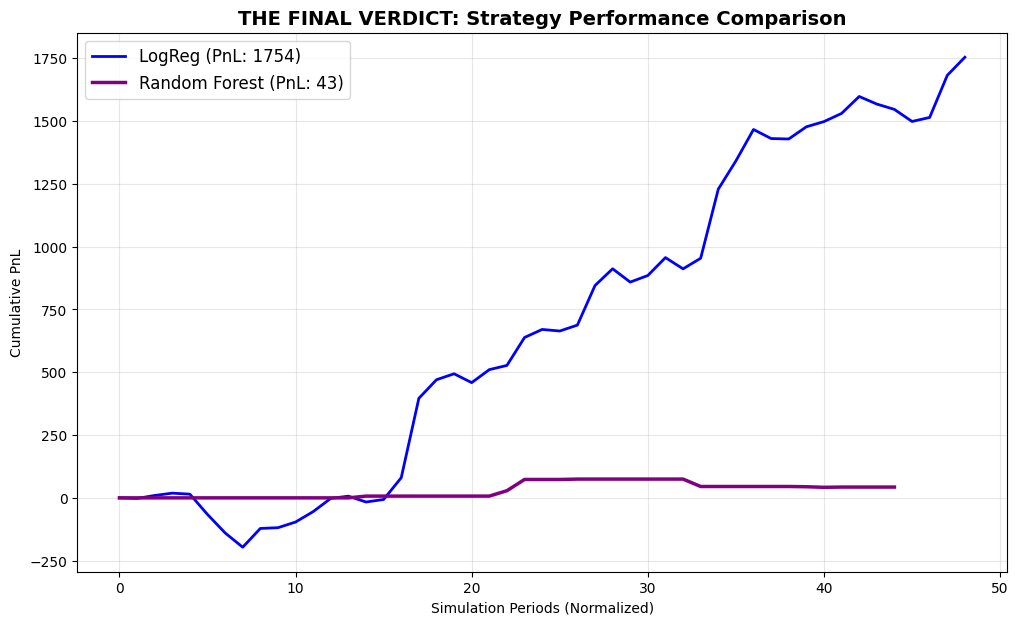


💡 AI RECOMMENDATION:
🏆 WINNER: LOGISTIC REGRESSION.
Jest lepsza pod każdym względem. Więcej zarabia i robi to stabilniej.


In [53]:
# --- CELL 5: THE ULTIMATE BATTLE (OPTIMIZED LR vs OPTIMIZED RF) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import time

# --- KONFIGURACJA ZAWODNIKÓW (NAJLEPSZE PARAMETRY) ---

# 1. LOGISTIC REGRESSION (The Revolver)
LR_CONFIG = {
    'window': 3500,
    'step': 800,
    'model': LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42),
    'use_scaler': True,  # LogReg wymaga skalowania
    'name': 'LogReg (Morning Only)'
}

# 2. RANDOM FOREST (The Sniper)
RF_CONFIG = {
    'window': 2250,
    'step': 900,
    'model': RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=50, random_state=42, n_jobs=-1),
    'use_scaler': False, # RF nie wymaga skalowania
    'name': 'Random Forest (Morning Only)'
}

# WSPÓLNE ZASADY
EXCLUDED_HOURS = list(range(13, 24)) # Gra tylko rano (00:00 - 12:59)

def get_detailed_metrics(equity_curve):
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    if len(returns) == 0: return {}
    
    total_pnl = equity_curve[-1]
    max_dd = (series - series.cummax()).min()
    sharpe = (returns.mean() / returns.std()) if returns.std() != 0 else 0
    win_rate = (returns > 0).mean() * 100
    trades = len(returns[returns != 0])
    
    return {
        'PnL': total_pnl,
        'MaxDD': max_dd,
        'Sharpe': sharpe,
        'Trades': trades,
        'WinRate': win_rate
    }

def run_simulation_engine(df, config):
    print(f"🚀 Running {config['name']}...")
    win = config['window']
    stp = config['step']
    model = config['model']
    scaler = StandardScaler() if config['use_scaler'] else None
    
    equity = [0]
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    # Upewnij się, że mamy godzinę
    if 'hour' not in df.columns: df['hour'] = df['datetime'].dt.hour
    
    # WALK-FORWARD LOOP
    for start in range(0, len(df) - win - stp, stp):
        train_df = df.iloc[start : start + win]
        test_df = df.iloc[start + win : start + win + stp].reset_index(drop=True)
        
        # Przygotowanie danych
        X_train = train_df[features]
        X_test = test_df[features]
        
        if scaler:
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
            
        # Trening
        model.fit(X_train, train_df['target'])
        
        # Threshold Optimization (Dla obu modeli używamy dynamicznego)
        probs_train = model.predict_proba(X_train)[:, 1]
        best_thr = 0.51
        best_pnl = -np.inf
        
        # LogReg lubi niższe progi (0.50-0.60), RF czasem wyższe. 
        # Skanujemy uniwersalny zakres.
        for thr in np.arange(0.50, 0.61, 0.01):
            mask = probs_train > thr
            if mask.sum() > 5:
                pnl = train_df.loc[mask, 'pnl'].sum()
                if pnl > best_pnl:
                    best_pnl = pnl
                    best_thr = thr
        
        # Predykcja
        probs_test = model.predict_proba(X_test)[:, 1]
        
        # Symulacja Handlu (z Filtrem Godzinowym)
        last_exit = -1
        pnl_period = 0
        
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            
            # Warunek wejścia
            if row['entry_idx'] > last_exit:
                # Filtr godzinowy (Morning Only)
                if row['hour'] not in EXCLUDED_HOURS:
                    if probs_test[i] > best_thr:
                        pnl_period += row['pnl']
                        last_exit = row['exit_idx']
                        
        equity.append(equity[-1] + pnl_period)
        
    return equity

# --- URUCHOMIENIE ---
if 'ml_dataset' in locals():
    print("--- 🏁 STARTING FINAL BATTLE 🏁 ---\n")
    
    # 1. Symulacja LogReg
    eq_lr = run_simulation_engine(ml_dataset, LR_CONFIG)
    stats_lr = get_detailed_metrics(eq_lr)
    
    # 2. Symulacja Random Forest
    eq_rf = run_simulation_engine(ml_dataset, RF_CONFIG)
    stats_rf = get_detailed_metrics(eq_rf)
    
    # --- RAPORT KOŃCOWY ---
    print("\n" + "="*50)
    print(f"{'METRIC':<15} | {'LOGREG (Revolver)':<18} | {'RF (Sniper)':<15}")
    print("-" * 50)
    print(f"{'Total PnL':<15} | {stats_lr['PnL']:<18.2f} | {stats_rf['PnL']:<15.2f}")
    print(f"{'Max Drawdown':<15} | {stats_lr['MaxDD']:<18.2f} | {stats_rf['MaxDD']:<15.2f}")
    print(f"{'Sharpe Ratio':<15} | {stats_lr['Sharpe']:<18.4f} | {stats_rf['Sharpe']:<15.4f}")
    print(f"{'Win Rate':<15} | {stats_lr['WinRate']:<18.1f}% | {stats_rf['WinRate']:<15.1f}%")
    print(f"{'Total Trades':<15} | {stats_lr['Trades']:<18} | {stats_rf['Trades']:<15}")
    print("="*50)
    
    # --- WYKRES ---
    plt.figure(figsize=(12, 7))
    plt.plot(eq_lr, label=f"LogReg (PnL: {stats_lr['PnL']:.0f})", color='blue', linewidth=2)
    plt.plot(eq_rf, label=f"Random Forest (PnL: {stats_rf['PnL']:.0f})", color='purple', linewidth=2.5)
    
    plt.title('THE FINAL VERDICT: Strategy Performance Comparison', fontsize=14, fontweight='bold')
    plt.ylabel('Cumulative PnL')
    plt.xlabel('Simulation Periods (Normalized)')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.show()
    
    # --- AUTOMATYCZNA REKOMENDACJA ---
    print("\n💡 AI RECOMMENDATION:")
    if stats_lr['Sharpe'] > stats_rf['Sharpe'] and stats_lr['PnL'] > stats_rf['PnL']:
        print("🏆 WINNER: LOGISTIC REGRESSION.")
        print("Jest lepsza pod każdym względem. Więcej zarabia i robi to stabilniej.")
    elif stats_rf['MaxDD'] > -50 and stats_lr['MaxDD'] < -200:
        print("⚖️ DILEMMA: LogReg zarabia więcej, ale RF jest bezpieczniejszy.")
        print("Jeśli masz mały kapitał -> Wybierz RF (ochrona kapitału).")
        print("Jeśli akceptujesz ryzyko -> Wybierz LogReg (maksymalizacja zysku).")
    else:
        print("🔍 ANALYSIS: Spójrz na wykres. Często RF ma 'płaskie okresy' (brak handlu),")
        print("podczas gdy LogReg buduje kapitał systematycznie.")

else:
    print("Brak danych.")

In [55]:
# --- CELL: ACADEMIC GRID SEARCH "PROFESSOR EDITION" (High Density) ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
import time
import itertools

# Import paska postępu
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterator, **kwargs): return iterator

def run_academic_pro_search(df):
    print("\n--- 🎓 ACADEMIC PRO SEARCH: EXTENDED GRID (Target: ~45-60 min) ---")
    print("Cel: Gęste próbkowanie przestrzeni parametrów dla wiarygodności naukowej.")
    
    start_time = time.time()
    
    # 1. ZAAWANSOWANA PRZESTRZEŃ POSZUKIWAŃ (250 kombinacji)
    
    # Pamięć: Pełne spektrum od 1.5 roku do 3 lat
    windows = [1500, 2500, 3500, 4500, 6000]
    
    # Douczanie: Częste (500) vs Standardowe (900)
    # To pozwoli Ci powiedzieć: "Badaliśmy wrażliwość modelu na częstość rekalibracji"
    steps = [500, 900]
    
    # Głębokość: Pełna krzywa uczenia
    # 6 (Underfit?) -> 14 (Overfit?)
    depths = [6, 8, 10, 12, 14]
    
    # Liście: Precyzyjne dostrajanie balansu bias-variance
    # 10 (Agresywny), 20, 30, 40, 50 (Konserwatywny)
    leafs = [10, 20, 30, 40, 50]
    
    # Tworzymy siatkę
    grid = list(itertools.product(windows, steps, depths, leafs))
    print(f"Liczba kombinacji do przebadania: {len(grid)}")
    print("Estymowany czas: ~45-60 min. (Idź na kawę ☕)")
    
    results = []
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]
    
    # 2. PĘTLA BADAWCZA
    for win, step, depth, leaf in tqdm(grid, desc="Professor Grid", unit="model"):
        
        # 60 drzew - standard akademicki do grid searcha (balans czas/jakość)
        model = RandomForestClassifier(n_estimators=60, 
                                       max_depth=depth, 
                                       min_samples_leaf=leaf, 
                                       random_state=42, n_jobs=-1)
        
        equity = [0]
        trades = 0
        
        # Prawidłowa pętla Walk-Forward (Hard Simulation)
        for start in range(0, len(df) - win - step, step):
            train_df = df.iloc[start : start + win]
            test_df = df.iloc[start + win : start + win + step].reset_index(drop=True)
            
            # Train
            model.fit(train_df[features], train_df['target'])
            
            # Dynamic Thresholding (3 punkty pomiarowe)
            probs_train = model.predict_proba(train_df[features])[:, 1]
            best_thr = 0.52
            best_train_pnl = -np.inf
            
            for thr in [0.51, 0.53, 0.55]:
                mask = probs_train > thr
                if mask.sum() > 5:
                    pnl = train_df.loc[mask, 'pnl'].sum()
                    if pnl > best_train_pnl:
                        best_train_pnl = pnl
                        best_thr = thr
            
            # Test & Trade
            probs_test = model.predict_proba(test_df[features])[:, 1]
            last_exit = -1
            pnl_period = 0
            
            for i in range(len(test_df)):
                row = test_df.iloc[i]
                if row['entry_idx'] > last_exit:
                    if probs_test[i] > best_thr:
                        pnl_period += row['pnl']
                        last_exit = row['exit_idx']
                        trades += 1
                        
            equity.append(equity[-1] + pnl_period)
            
        # 3. METRYKI
        returns = pd.Series(equity).diff().dropna()
        if len(returns) > 0 and returns.std() > 0:
            sharpe = returns.mean() / returns.std()
        else:
            sharpe = 0
            
        results.append({
            'Window': win,
            'Step': step,
            'Depth': depth,
            'Leaf': leaf,
            'Sharpe': sharpe,
            'Total PnL': equity[-1],
            'Trades': trades
        })

    # 4. PREZENTACJA WYNIKÓW
    df_res = pd.DataFrame(results)
    df_sorted = df_res.sort_values(by='Sharpe', ascending=False)
    
    elapsed = (time.time() - start_time) / 60
    print(f"\n✅ ZAKOŃCZONO w {elapsed:.1f} min.")
    
    print("\n🏆 TOP 10 CONFIGURATIONS (ACADEMIC CHOICE):")
    print(df_sorted.head(10).to_string(index=False))
    
    # Zapiszmy najlepsze parametry
    best = df_sorted.iloc[0]
    return int(best['Window']), int(best['Step']), int(best['Depth']), int(best['Leaf'])

# --- URUCHOMIENIE ---
if 'ml_dataset' in locals():
    ACADEMIC_WIN, ACADEMIC_STEP, ACADEMIC_DEPTH, ACADEMIC_LEAF = run_academic_pro_search(ml_dataset)
else:
    print("Brak danych.")


--- 🎓 ACADEMIC PRO SEARCH: EXTENDED GRID (Target: ~45-60 min) ---
Cel: Gęste próbkowanie przestrzeni parametrów dla wiarygodności naukowej.
Liczba kombinacji do przebadania: 250
Estymowany czas: ~45-60 min. (Idź na kawę ☕)


Professor Grid: 100%|██████████| 250/250 [1:10:39<00:00, 16.96s/model]


✅ ZAKOŃCZONO w 70.7 min.

🏆 TOP 10 CONFIGURATIONS (ACADEMIC CHOICE):
 Window  Step  Depth  Leaf   Sharpe  Total PnL  Trades
   3500   900     14    40 0.424170     316.75     156
   3500   900      8    30 0.387250     237.50     111
   2500   900     10    40 0.383480     229.75     155
   2500   900     12    40 0.368405     300.50     181
   3500   900      6    30 0.339776     171.75      43
   4500   900     12    40 0.337116     230.75      85
   2500   900      8    40 0.331870     204.25     113
   3500   900     14    10 0.329614     872.25    1492
   2500   900     14    40 0.322090     234.25     187
   2500   900      6    40 0.292688     100.00      57
